# IMPORT LIBRARIES & LOAD DATASET

In [51]:
import pandas as pd
import numpy as np
from sklearn import datasets, linear_model
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import statsmodels.api as sm
import statsmodels.formula.api as smf

In [52]:
womens_world_cup_stats = pd.read_csv(
    '/Users/gui/womens_world_cup_2023_statsbomb_plusplus.csv'
)

In [53]:
womens_world_cup_stats

,match_id,match_date,team,opponent,stage,goals_for,goals_against,result,points,possession_pct,...,dribbles,successful_dribbles,dribble_success_pct,duels,duels_won,counterpress_actions,goals_from_shots,own_goals_for,own_goals_against,goal_type
0,3893787,2023-07-20,New Zealand Women's,Norway Women's,Group,1,0,W,3,57.781529,...,NaN,NaN,NaN,NaN,NaN,NaN,1,0,0,Goal
1,3893787,2023-07-20,Norway Women's,New Zealand Women's,Group,0,1,L,0,42.218471,...,NaN,NaN,NaN,NaN,NaN,NaN,0,0,0,Goal
2,3893788,2023-07-20,Australia Women's,Republic of Ireland Women's,Group,1,0,W,3,58.013378,...,NaN,NaN,NaN,NaN,NaN,NaN,1,0,0,Goal
3,3893788,2023-07-20,Republic of Ireland Women's,Australia Women's,Group,0,1,L,0,41.986622,...,NaN,NaN,NaN,NaN,NaN,NaN,0,0,0,Goal
4,3893789,2023-07-21,Philippines Women's,Switzerland Women's,Group,0,2,L,0,30.212373,...,NaN,NaN,NaN,NaN,NaN,NaN,0,0,0,Goal
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
123,3904629,2023-08-16,England Women's,Australia Women's,Semi-finals,3,1,W,3,49.971523,...,NaN,NaN,NaN,NaN,NaN,NaN,3,0,0,Goal
124,3906389,2023-08-19,Australia Women's,Sweden Women's,Third-place,0,2,L,0,52.821967,...,NaN,NaN,NaN,NaN,NaN,NaN,0,0,0,Goal
125,3906389,2023-08-19,Sweden Women's,Australia Women's,Third-place,2,0,W,3,47.178033,...,NaN,NaN,NaN,NaN,NaN,NaN,2,0,0,Goal
126,3906390,2023-08-20,England Women's,Spain Women's,Final,0,1,L,0,44.284665,...,NaN,NaN,NaN,NaN,NaN,NaN,0,0,0,Goal


# FILTER ROUND OF 16

In [55]:
r16 = womens_world_cup_stats[
    womens_world_cup_stats['stage'] == 'Round of 16'
]

In [56]:
r16

,match_id,match_date,team,opponent,stage,goals_for,goals_against,result,points,possession_pct,...,dribbles,successful_dribbles,dribble_success_pct,duels,duels_won,counterpress_actions,goals_from_shots,own_goals_for,own_goals_against,goal_type
96,3901733,2023-08-05,Spain Women's,Switzerland Women's,Round of 16,5,1,W,3,68.915293,...,12.0,9.0,75.00,28.0,12.0,65.0,5,0,1,Goal
97,3901733,2023-08-05,Switzerland Women's,Spain Women's,Round of 16,1,5,L,0,31.084707,...,9.0,5.0,55.56,38.0,12.0,67.0,0,1,0,Goal + Own Goal
98,3901734,2023-08-05,Japan Women's,Norway Women's,Round of 16,3,1,W,3,59.219881,...,2.0,1.0,50.00,38.0,8.0,49.0,2,1,0,Goal + Own Goal
99,3901734,2023-08-05,Norway Women's,Japan Women's,Round of 16,1,3,L,0,40.780119,...,9.0,2.0,22.22,22.0,3.0,50.0,1,0,1,Goal
100,3901796,2023-08-06,Netherlands Women's,South Africa Women's,Round of 16,2,0,W,3,70.757060,...,13.0,5.0,38.46,41.0,20.0,79.0,2,0,0,Goal
101,3901796,2023-08-06,South Africa Women's,Netherlands Women's,Round of 16,0,2,L,0,29.242940,...,35.0,18.0,51.43,45.0,14.0,56.0,0,0,0,Goal
102,3901797,2023-08-06,Sweden Women's,United States Women's,Round of 16,0,0,D,1,39.728930,...,10.0,3.0,30.00,54.0,14.0,82.0,0,0,0,Goal
103,3901797,2023-08-06,United States Women's,Sweden Women's,Round of 16,0,0,D,1,60.271070,...,25.0,18.0,72.00,53.0,16.0,70.0,0,0,0,Goal
104,3901735,2023-08-07,England Women's,Nigeria Women's,Round of 16,0,0,D,1,49.948365,...,18.0,7.0,38.89,54.0,11.0,55.0,0,0,0,Goal
105,3901735,2023-08-07,Nigeria Women's,England Women's,Round of 16,0,0,D,1,50.051635,...,16.0,7.0,43.75,57.0,20.0,74.0,0,0,0,Goal


## FILTER JUST THE GAMES

In [58]:
games = womens_world_cup_stats[
    womens_world_cup_stats["stage"] == "Round of 16"
]

games[
    ["match_id", "team", "opponent", "stage"]
].drop_duplicates("match_id")

,match_id,team,opponent,stage
96,3901733,Spain Women's,Switzerland Women's,Round of 16
98,3901734,Japan Women's,Norway Women's,Round of 16
100,3901796,Netherlands Women's,South Africa Women's,Round of 16
102,3901797,Sweden Women's,United States Women's,Round of 16
104,3901735,England Women's,Nigeria Women's,Round of 16
106,3901736,Australia Women's,Denmark Women's,Round of 16
108,3901832,Colombia Women's,Jamaica Women's,Round of 16
110,3901833,France Women's,Morocco Women's,Round of 16


# GAME ANALYSIS SPA-SWI

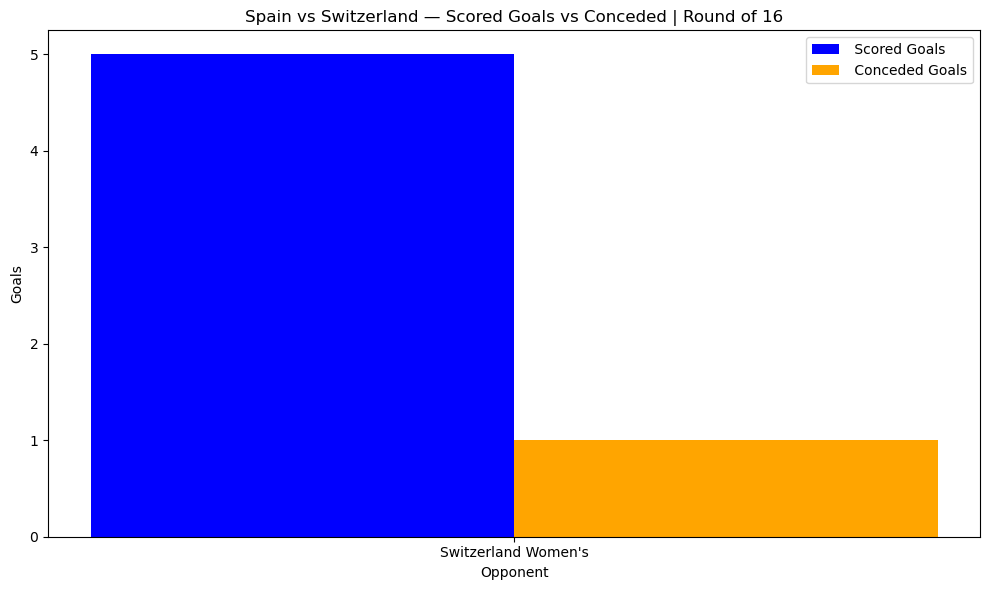

In [60]:
r16 = womens_world_cup_stats[
    (womens_world_cup_stats["team"] == "Spain Women's") &
    (womens_world_cup_stats["stage"] == "Round of 16")
].copy()

r16["match_date"] = pd.to_datetime(r16["match_date"])

r16 = r16.sort_values("match_date")

x = np.arange(len(r16))
width = 0.35

plt.figure(figsize=(10, 6))

plt.bar(
    x - width / 2,
    r16["goals_for"],
    width,
    label=" Scored Goals",
    color = "blue"
)

plt.bar(
    x + width / 2,
    r16["goals_against"],
    width,
    label= " Conceded Goals",
    color = "orange"
)

plt.xticks(
    x,
    r16["opponent"]
)

plt.xlabel("Opponent")
plt.ylabel("Goals")
plt.title("Spain vs Switzerland — Scored Goals vs Conceded | Round of 16")

plt.legend()

plt.tight_layout()
plt.show()

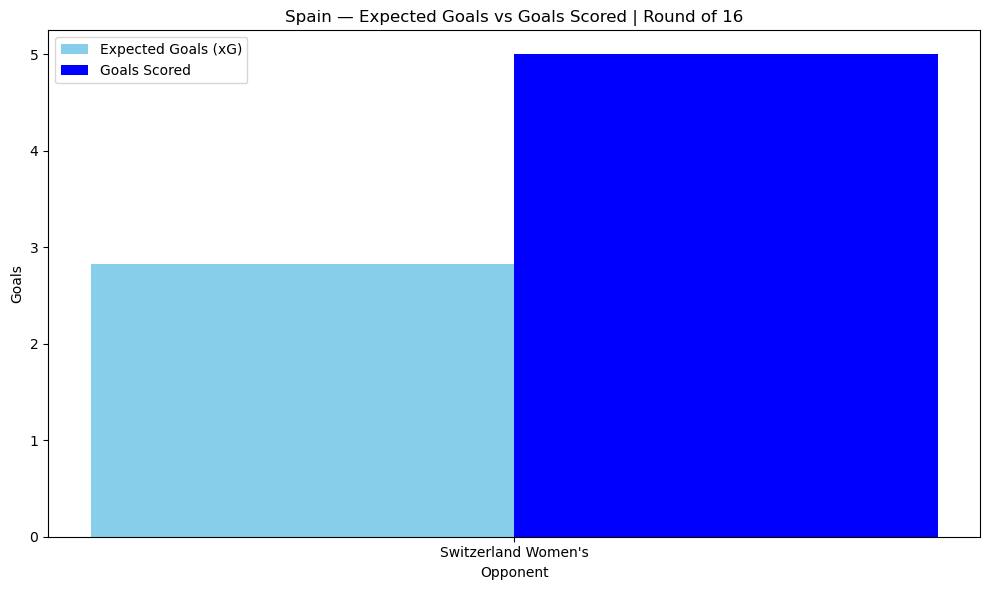

In [61]:
r16 = womens_world_cup_stats[
    (womens_world_cup_stats["team"] == "Spain Women's") &
    (womens_world_cup_stats["stage"] == "Round of 16")
].copy()

r16["match_date"] = pd.to_datetime(r16["match_date"])

r16 = r16.sort_values("match_date")

x = np.arange(len(r16))
width = 0.35

plt.figure(figsize=(10, 6))

plt.bar(
    x - width / 2,
    r16["xG"],
    width,
    label="Expected Goals (xG)",
    color="skyblue"
)

plt.bar(
    x + width / 2,
    r16["goals_for"],
    width,
    label="Goals Scored",
    color="blue"
)

plt.xticks(
    x,
    r16["opponent"]
)

plt.xlabel("Opponent")
plt.ylabel("Goals")
plt.title("Spain — Expected Goals vs Goals Scored | Round of 16")

plt.legend()

plt.tight_layout()
plt.show()

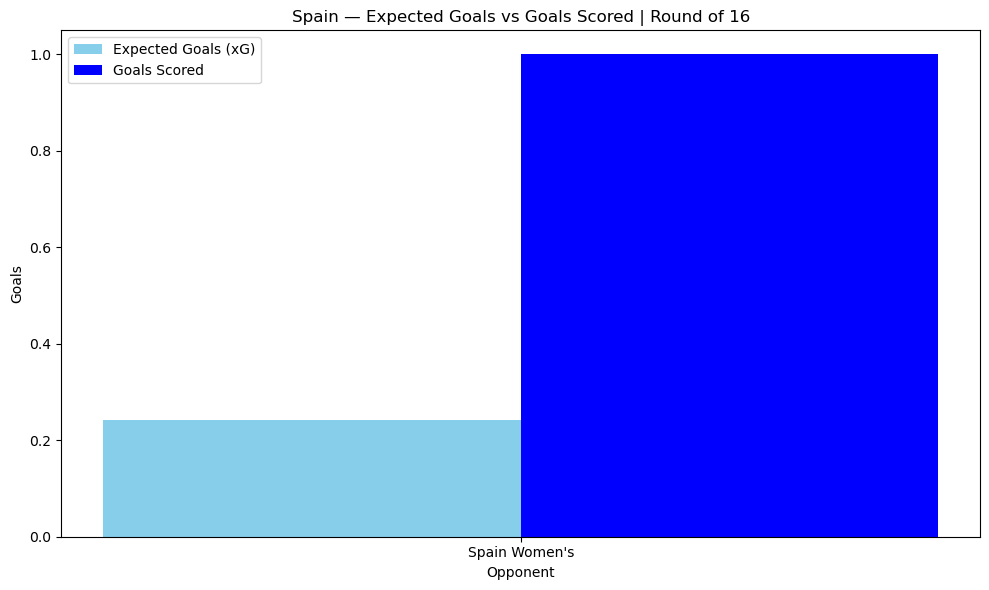

In [62]:
r16 = womens_world_cup_stats[
    (womens_world_cup_stats["team"] == "Switzerland Women's") &
    (womens_world_cup_stats["stage"] == "Round of 16")
].copy()

r16["match_date"] = pd.to_datetime(r16["match_date"])

r16 = r16.sort_values("match_date")

x = np.arange(len(r16))
width = 0.35

plt.figure(figsize=(10, 6))

plt.bar(
    x - width / 2,
    r16["xG"],
    width,
    label="Expected Goals (xG)",
    color="skyblue"
)

plt.bar(
    x + width / 2,
    r16["goals_for"],
    width,
    label="Goals Scored",
    color="blue"
)

plt.xticks(
    x,
    r16["opponent"]
)

plt.xlabel("Opponent")
plt.ylabel("Goals")
plt.title("Spain — Expected Goals vs Goals Scored | Round of 16")

plt.legend()

plt.tight_layout()
plt.show()

Spain won its Round of 16 match against Switzerland 5-1.
Both teams advanced from the group stage, with Spain finishing in second place and Switzerland in first.
Both teams outperformed their xG, demonstrating a better-than-expected performance compared to their early matches in the tournament. 

In [111]:
match = womens_world_cup_stats[
    (
        (womens_world_cup_stats["team"] == "Spain Women's") &
        (womens_world_cup_stats["opponent"] == "Switzerland Women's")
    ) |
    (
        (womens_world_cup_stats["team"] == "Switzerland Women's") &
        (womens_world_cup_stats["opponent"] == "Spain Women's")
    )
].copy()


# Metrics to compare

metrics = {
    "Goals": "goals_for",
    "xG": "xG",
    "Goals Minus xG": "goals_minus_xG",
    "Shots": "shots",
    "Shots on Target": "shots_on_target",
    "Saves": "saves",
    "Possession %": "possession_pct",
    "Pass Accuracy %": "pass_accuracy_pct",
    "Progressive Passes": "progressive_passes",
    "Progressive Carries": "progressive_carries",
    "Final Third Entries": "final_third_entries",
    "Box Entries": "box_entries",
    "High Turnovers": "high_turnovers",
    "Tackles Won": "tackles_won",
    "Interceptions": "interceptions",
    "Blocks": "blocks",
    "Clearances": "clearances",
    "Recoveries": "recoveries",
    "Goals from Shots": "goals_from_shots",
    "Own Goals From": "own_goals_for",	
    "Own Goals Against": "own_goals_against",	
    "Goal type": "goal_type"
}


# Create comparison table

comparison = pd.DataFrame({
    "Metric": metrics.keys(),

    "Spain": [
        match.loc[
            match["team"] == "Spain Women's", column
        ].iloc[0]
        for column in metrics.values()
    ],

    "Switzerland": [
        match.loc[
            match["team"] == "Switzerland Women's", column
        ].iloc[0]
        for column in metrics.values()
    ]
})


# Round selected metrics to 1 decimal place

decimal_metrics = [
    "xG",
    "Goals Minus xG",
    "Possession %",
    "Pass Accuracy %"
]

comparison.loc[
    comparison["Metric"].isin(decimal_metrics),
    ["Spain", "Switzerland"]
] = comparison.loc[
    comparison["Metric"].isin(decimal_metrics),
    ["Spain", "Switzerland"]
].round(1)


# Display table

comparison

,Metric,Spain,Switzerland
0,Goals,5,1
1,xG,2.828263,0.242318
2,Goals Minus xG,2.171737,0.757682
3,Shots,26,2
4,Shots on Target,10,1
5,Saves,1,5
6,Possession %,68.915293,31.084707
7,Pass Accuracy %,85.812672,69.254658
8,Progressive Passes,148.0,76.0
9,Progressive Carries,39.0,10.0


### Correction of an Error

In [66]:
match["calculated_goals_minus_xG"] = (
    match["goals_for"] - match["xG"]
)

match[[
    "team",
    "goals_for",
    "xG",
    "goals_minus_xG",
    "calculated_goals_minus_xG"
]]

,team,goals_for,xG,goals_minus_xG,calculated_goals_minus_xG
96,Spain Women's,5,2.828263,2.171737,2.171737
97,Switzerland Women's,1,0.242318,-0.242318,0.757682


In [67]:
womens_world_cup_stats["goals_minus_xG"] = (
    womens_world_cup_stats["goals_for"]
    - womens_world_cup_stats["xG"]
)

## - 

Teams found:
["Spain Women's" "Switzerland Women's"]


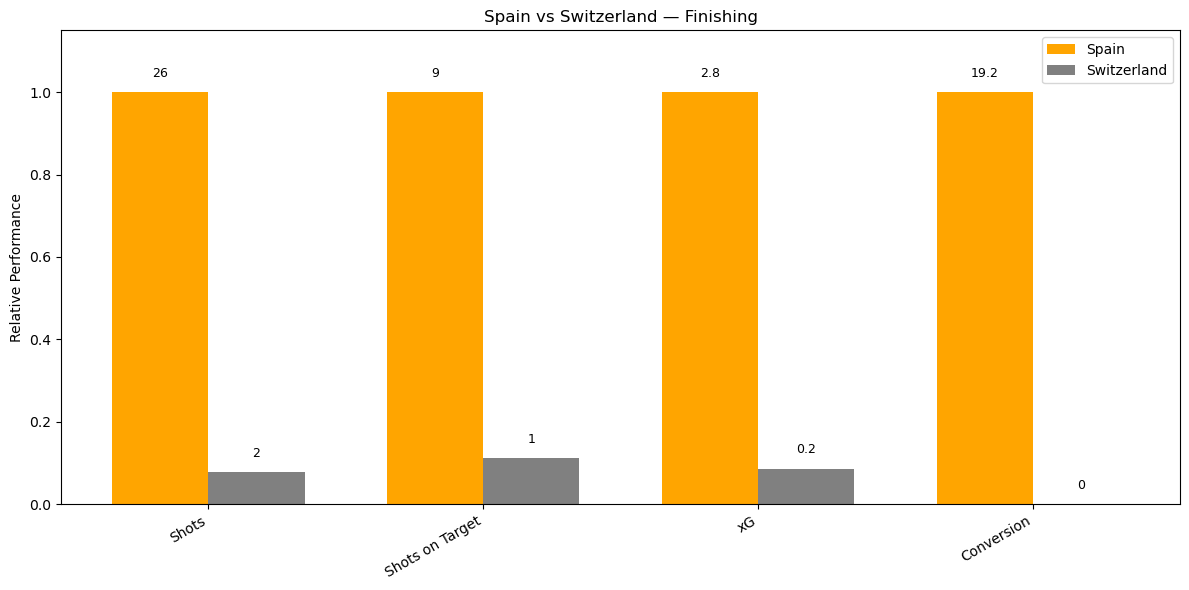

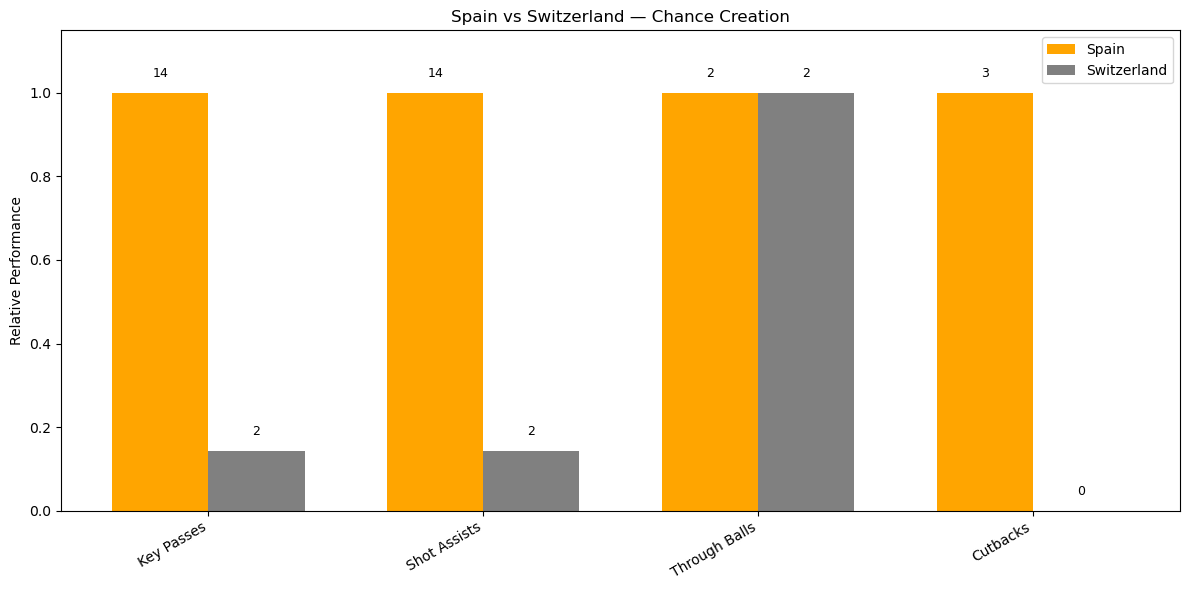

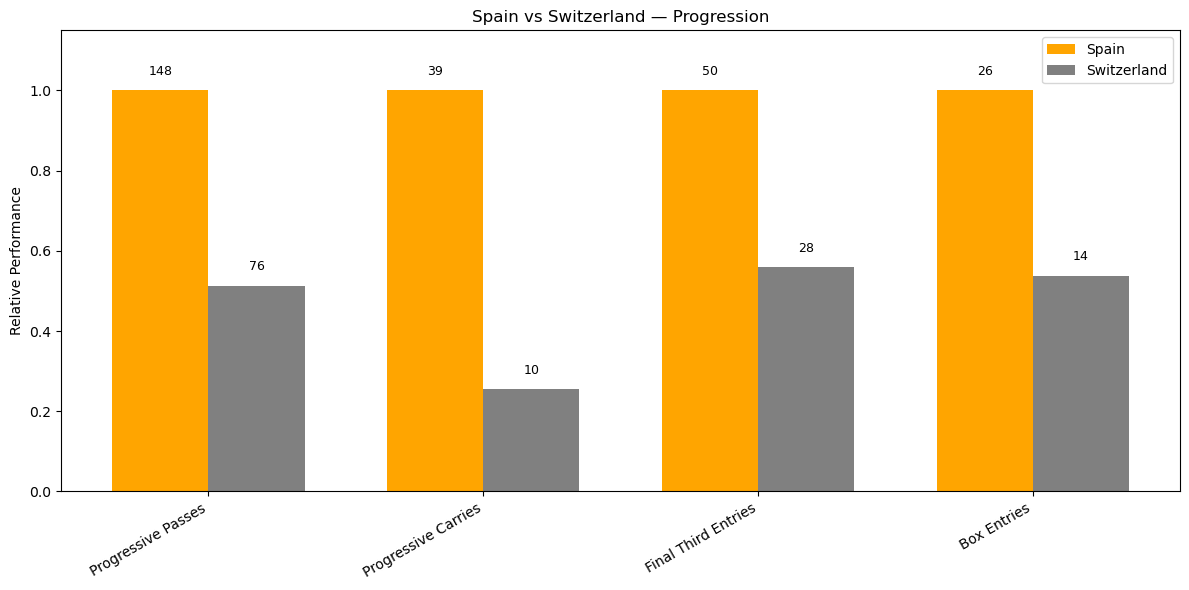

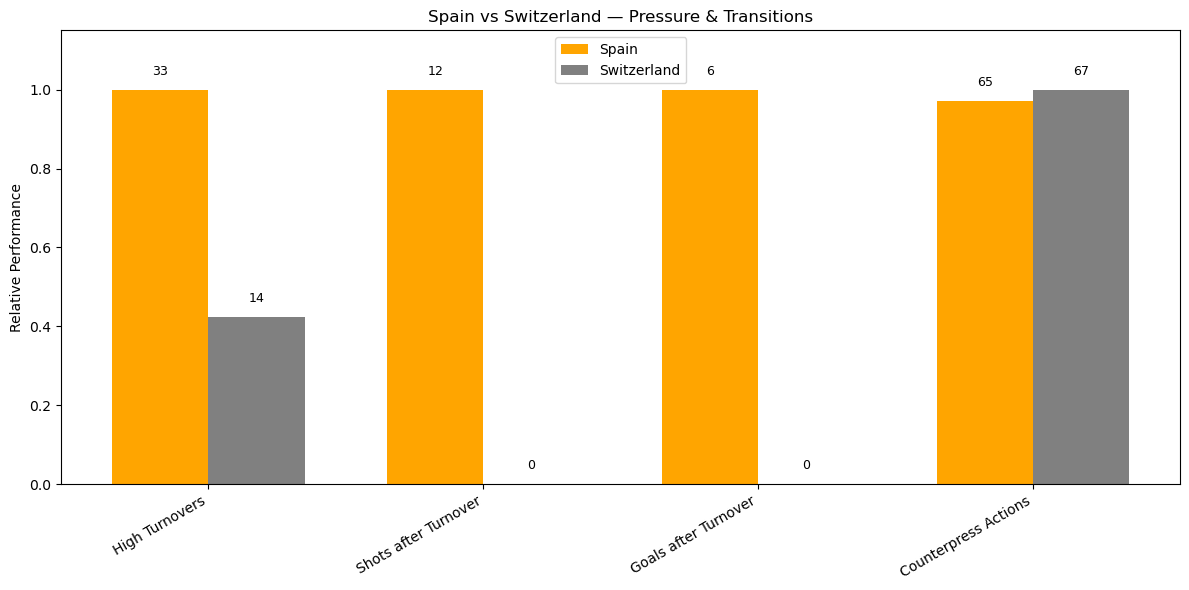

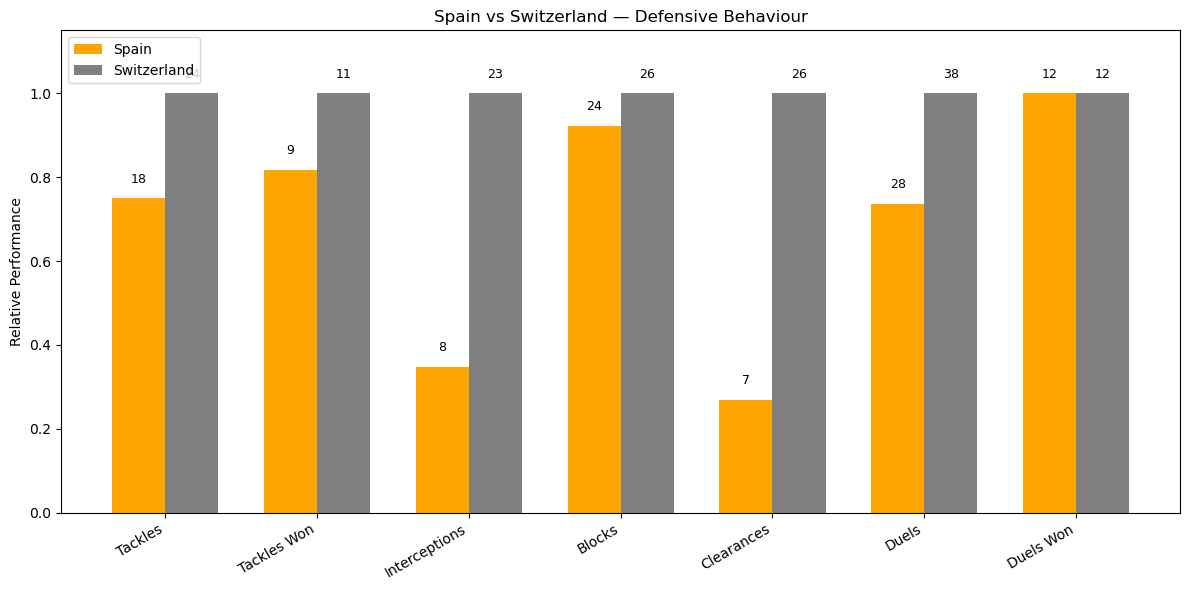

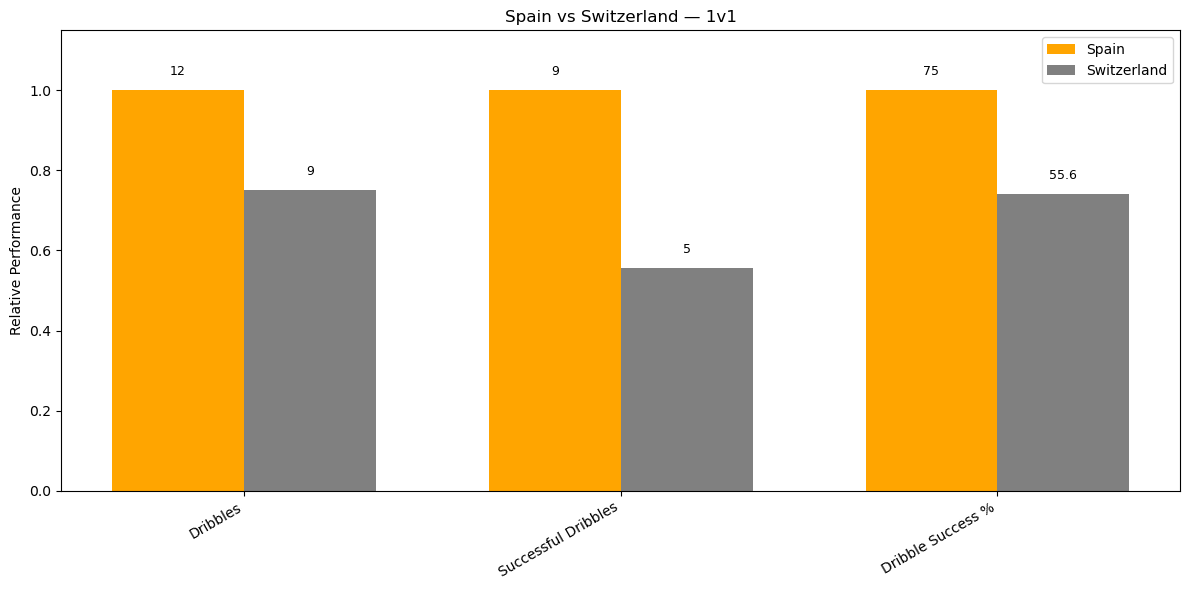

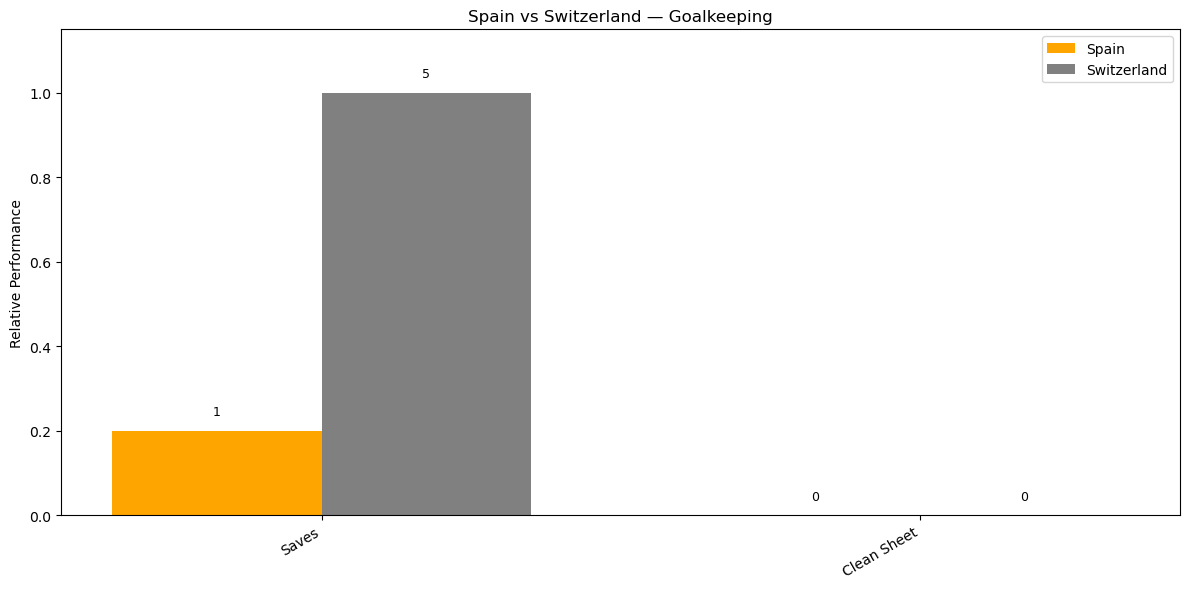

In [69]:
import matplotlib.pyplot as plt
import numpy as np

match = womens_world_cup_stats[
    (
        (
            (womens_world_cup_stats["team"] == "Spain Women's") &
            (womens_world_cup_stats["opponent"] == "Switzerland Women's")
        )
        |
        (
            (womens_world_cup_stats["team"] == "Switzerland Women's") &
            (womens_world_cup_stats["opponent"] == "Spain Women's")
        )
    )
    &
    (womens_world_cup_stats["stage"] == "Round of 16")
].copy()


# ============================================================
# 2. TEAM NAMES
# ============================================================

team_names = {
    "Spain": "Spain Women's",
    "Switzerland": "Switzerland Women's"
}


# ============================================================
# 3. METRICS BY CATEGORY
# ============================================================

categories = {


    "Finishing": {
        "Shots": "shots",
        "Shots on Target": "shots_on_target",
        "xG": "xG",
        "Conversion": "conversion_pct"
    },


     "Chance Creation": {
        "Key Passes": "key_passes",
        "Shot Assists": "shot_assists",
        "Through Balls": "through_balls",
        "Cutbacks": "cutbacks"
    },



    "Progression": {
        "Progressive Passes": "progressive_passes",
        "Progressive Carries": "progressive_carries",
        "Final Third Entries": "final_third_entries",
        "Box Entries": "box_entries"
    },



    "Pressure & Transitions": {
        "High Turnovers": "high_turnovers",
        "Shots after Turnover": "shots_after_turnover",
        "Goals after Turnover": "goals_after_turnover",
        "Counterpress Actions": "counterpress_actions"
    },



    "Defensive Behaviour": {
        "Tackles": "tackles",
        "Tackles Won": "tackles_won",
        "Interceptions": "interceptions",
        "Blocks": "blocks",
        "Clearances": "clearances",
        "Duels": "duels",
        "Duels Won": "duels_won"
    },



    "1v1": {
        "Dribbles": "dribbles",
        "Successful Dribbles": "successful_dribbles",
        "Dribble Success %": "dribble_success_pct"
    },



    "Goalkeeping": {
        "Saves": "saves",
        "Clean Sheet": "clean_sheet"
    }
}


# ============================================================
# 4. CHECK TEAMS
# ============================================================

print("Teams found:")
print(match["team"].unique())


# ============================================================
# 5. CREATE EACH CHART
# ============================================================

for category_name, metrics in categories.items():

    # --------------------------------------------------------
    # Get real values
    # --------------------------------------------------------

    spa_values = np.array([
        match.loc[
            match["team"] == team_names["Spain"],
            column
        ].iloc[0]
        for column in metrics.values()
    ], dtype=float)


    swi_values = np.array([
        match.loc[
            match["team"] == team_names["Switzerland"],
            column
        ].iloc[0]
        for column in metrics.values()
    ], dtype=float)


    # --------------------------------------------------------
    # Maximum value for each metric
    # --------------------------------------------------------

    max_values = np.maximum(
        spa_values,
        swi_values
    )


    # --------------------------------------------------------
    # Normalize
    # --------------------------------------------------------

    spa_normalized = np.divide(
        spa_values,
        max_values,
        out=np.zeros_like(spa_values),
        where=max_values != 0
    )


    swi_normalized = np.divide(
        swi_values,
        max_values,
        out=np.zeros_like(swi_values),
        where=max_values != 0
    )


    # --------------------------------------------------------
    # Position of bars
    # --------------------------------------------------------

    x = np.arange(len(metrics))
    width = 0.35


    # --------------------------------------------------------
    # Create figure
    # --------------------------------------------------------

    plt.figure(figsize=(12, 6))


    bars_spa = plt.bar(
        x - width / 2,
        spa_normalized,
        width,
        label="Spain",
        color="orange"
    )


    bars_swi = plt.bar(
        x + width / 2,
        swi_normalized,
        width,
        label="Switzerland",
        color="gray"
    )


    # ========================================================
    # REAL VALUES ABOVE BARS
    # ========================================================

    for bar, value in zip(
        bars_spa,
        spa_values
    ):

        if value.is_integer():
            label = f"{int(value)}"
        else:
            label = f"{value:.1f}"

        plt.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.03,
            label,
            ha="center",
            va="bottom",
            fontsize=9
        )


    for bar, value in zip(
        bars_swi,
        swi_values
    ):

        if value.is_integer():
            label = f"{int(value)}"
        else:
            label = f"{value:.1f}"

        plt.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.03,
            label,
            ha="center",
            va="bottom",
            fontsize=9
        )


    # ========================================================
    # LABELS
    # ========================================================

    plt.xticks(
        x,
        metrics.keys(),
        rotation=30,
        ha="right"
    )

    plt.ylabel("Relative Performance")

    plt.title(
        f"Spain vs Switzerland — {category_name}"
    )

    plt.ylim(0, 1.15)

    plt.legend()

    plt.tight_layout()

    plt.show()

In [70]:
womens_world_cup_stats.loc[
    (
        (womens_world_cup_stats["match_id"] == 3901733) &
        (womens_world_cup_stats["team"] == "Spain Women's")
    ),
    "shots_on_target"
] = 10

womens_world_cup_stats.loc[
    (
        (womens_world_cup_stats["match_id"] == 3901733) &
        (womens_world_cup_stats["team"] == "Switzerland Women's")
    ),
    "shots_on_target"
] = 1

In [71]:
match = womens_world_cup_stats[
    (
        (
            (womens_world_cup_stats["team"] == "Spain Women's") &
            (womens_world_cup_stats["opponent"] == "Switzerland Women's")
        )
        |
        (
            (womens_world_cup_stats["team"] == "Switzerland Women's") &
            (womens_world_cup_stats["opponent"] == "Spain Women's")
        )
    )
    &
    (womens_world_cup_stats["stage"] == "Round of 16")
].copy()

match[[
    "team",
    "goals_for",
    "shots",
    "shots_on_target",
    "saves"
]]

,team,goals_for,shots,shots_on_target,saves
96,Spain Women's,5,26,10,1
97,Switzerland Women's,1,2,1,5


In [72]:
match[[
    "team",
    "opponent",
    "formation"
]]

,team,opponent,formation
96,Spain Women's,Switzerland Women's,4-3-3
97,Switzerland Women's,Spain Women's,4-3-3


In [73]:
formation_comparison = pd.DataFrame({
    "Metric": [
        "Formation",
        "Possession %",
        "Shots",
        "xG",
        "Progressive Passes",
        "Progressive Carries",
        "Final Third Entries",
        "Box Entries",
        "High Turnovers",
        "Interceptions",
        "Clearances"
    ],

    "Spain": [
        match.loc[
            match["team"] == "Spain Women's",
            "formation"
        ].iloc[0],
        
        match.loc[
            match["team"] == "Spain Women's",
            "possession_pct"
        ].iloc[0],
        
        match.loc[
            match["team"] == "Spain Women's",
            "shots"
        ].iloc[0],
        
        match.loc[
            match["team"] == "Spain Women's",
            "xG"
        ].iloc[0],
        
        match.loc[
            match["team"] == "Spain Women's",
            "progressive_passes"
        ].iloc[0],
        
        match.loc[
            match["team"] == "Spain Women's",
            "progressive_carries"
        ].iloc[0],
        
        match.loc[
            match["team"] == "Spain Women's",
            "final_third_entries"
        ].iloc[0],
        
        match.loc[
            match["team"] == "Spain Women's",
            "box_entries"
        ].iloc[0],
        
        match.loc[
            match["team"] == "Spain Women's",
            "high_turnovers"
        ].iloc[0],
        
        match.loc[
            match["team"] == "Spain Women's",
            "interceptions"
        ].iloc[0],
        
        match.loc[
            match["team"] == "Spain Women's",
            "clearances"
        ].iloc[0]
    ],

    "Switzerland": [
        match.loc[
            match["team"] == "Switzerland Women's",
            "formation"
        ].iloc[0],
        
        match.loc[
            match["team"] == "Switzerland Women's",
            "possession_pct"
        ].iloc[0],
        
        match.loc[
            match["team"] == "Switzerland Women's",
            "shots"
        ].iloc[0],
        
        match.loc[
            match["team"] == "Switzerland Women's",
            "xG"
        ].iloc[0],
        
        match.loc[
            match["team"] == "Switzerland Women's",
            "progressive_passes"
        ].iloc[0],
        
        match.loc[
            match["team"] == "Switzerland Women's",
            "progressive_carries"
        ].iloc[0],
        
        match.loc[
            match["team"] == "Switzerland Women's",
            "final_third_entries"
        ].iloc[0],
        
        match.loc[
            match["team"] == "Switzerland Women's",
            "box_entries"
        ].iloc[0],
        
        match.loc[
            match["team"] == "Switzerland Women's",
            "high_turnovers"
        ].iloc[0],
        
        match.loc[
            match["team"] == "Switzerland Women's",
            "interceptions"
        ].iloc[0],
        
        match.loc[
            match["team"] == "Switzerland Women's",
            "clearances"
        ].iloc[0]
    ]
})

# Arredondar percentagens e xG
formation_comparison.loc[
    formation_comparison["Metric"].isin(
        ["Possession %", "xG"]
    ),
    ["Spain", "Switzerland"]
] = formation_comparison.loc[
    formation_comparison["Metric"].isin(
        ["Possession %", "xG"]
    ),
    ["Spain", "Switzerland"]
].round(1)

formation_comparison

,Metric,Spain,Switzerland
0,Formation,4-3-3,4-3-3
1,Possession %,68.915293,31.084707
2,Shots,26,2
3,xG,2.828263,0.242318
4,Progressive Passes,148.0,76.0
5,Progressive Carries,39.0,10.0
6,Final Third Entries,50.0,28.0
7,Box Entries,26.0,14.0
8,High Turnovers,33.0,14.0
9,Interceptions,8,23


## CONCLUSION OF SPA-SWI

The match presents a **contrast** between territorial **dominance and finishing efficiency**. Spain controlled the game through 
**possession, progressive play and repeated entries into the final third and penalty area, ultimately scoring five goals**. Switzerland, meanwhile, adopted a **predominantly defensive approach**, reflected in its higher number of interceptions, clearances and tackles won. Although this strategy limited Switzerland's attacking output to just two shots, it did not prevent Spain from creating sustained pressure. Interestingly, Switzerland displayed greater finishing efficiency, scoring once from only two shots (50% conversion), compared with Spain's 19.2%. Therefore, while Spain clearly dominated the match in terms of territory, possession and attacking volume, Switzerland's defensive approach did have some effect on limiting the quality and frequency of its attacking opportunities, but ultimately could not withstand Spain's sustained pressure.

**Spain and Switzerland started with a 4-3-3 formation, but their tactics and consistency differed**. Spain's 4-3-3 was **proactive and pro-pass**, with possession, progressive passing, frequent entries, and sustained pressure. This consistency led to more attacking play and five goals. Switzerland's **defensive execution**, reflected in interceptions, blocks and clearances, meant they scored less. **This shows that the same formation can produce very different outcomes depending on execution**.

# GAME ANALYSIS JAP-NOR

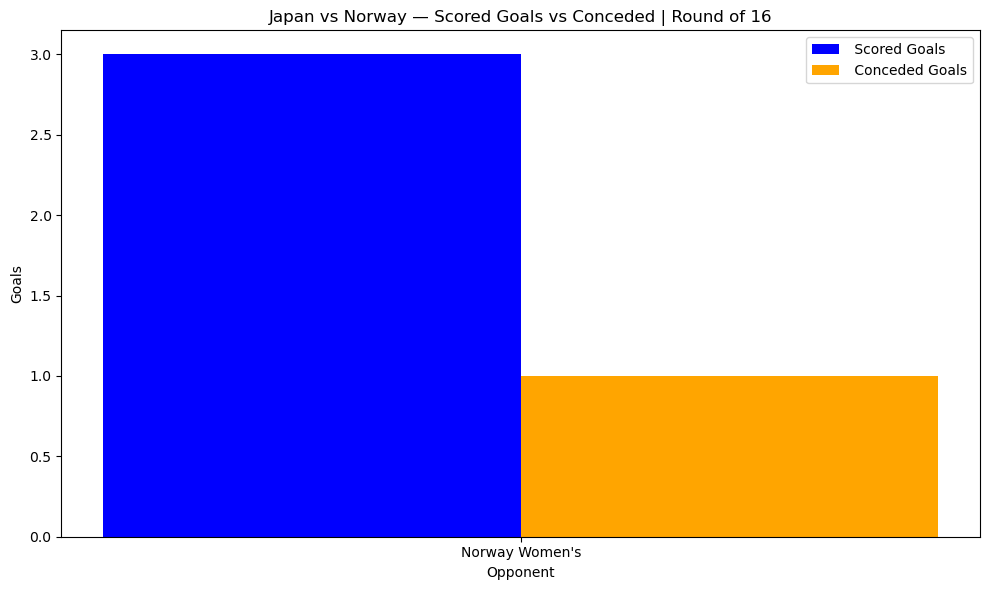

In [77]:
r16 = womens_world_cup_stats[
    (womens_world_cup_stats["team"] == "Japan Women's") &
    (womens_world_cup_stats["stage"] == "Round of 16")
].copy()

r16["match_date"] = pd.to_datetime(r16["match_date"])

r16 = r16.sort_values("match_date")

x = np.arange(len(r16))
width = 0.35

plt.figure(figsize=(10, 6))

plt.bar(
    x - width / 2,
    r16["goals_for"],
    width,
    label=" Scored Goals",
    color = "blue"
)

plt.bar(
    x + width / 2,
    r16["goals_against"],
    width,
    label= " Conceded Goals",
    color = "orange"
)

plt.xticks(
    x,
    r16["opponent"]
)

plt.xlabel("Opponent")
plt.ylabel("Goals")
plt.title("Japan vs Norway — Scored Goals vs Conceded | Round of 16")

plt.legend()

plt.tight_layout()
plt.show()

Japan won the match against Norway by scoring 3 goals. However, they also conceded 1 goal from the opponent.

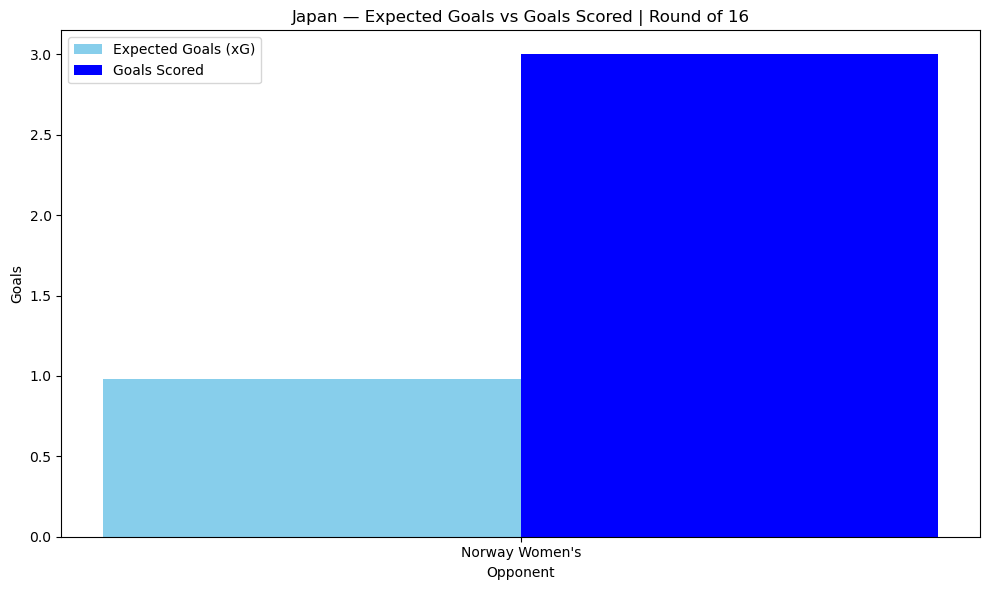

In [79]:
r16 = womens_world_cup_stats[
    (womens_world_cup_stats["team"] == "Japan Women's") &
    (womens_world_cup_stats["stage"] == "Round of 16")
].copy()

r16["match_date"] = pd.to_datetime(r16["match_date"])

r16 = r16.sort_values("match_date")

x = np.arange(len(r16))
width = 0.35

plt.figure(figsize=(10, 6))

plt.bar(
    x - width / 2,
    r16["xG"],
    width,
    label="Expected Goals (xG)",
    color="skyblue"
)

plt.bar(
    x + width / 2,
    r16["goals_for"],
    width,
    label="Goals Scored",
    color="blue"
)

plt.xticks(
    x,
    r16["opponent"]
)

plt.xlabel("Opponent")
plt.ylabel("Goals")
plt.title("Japan — Expected Goals vs Goals Scored | Round of 16")

plt.legend()

plt.tight_layout()
plt.show()

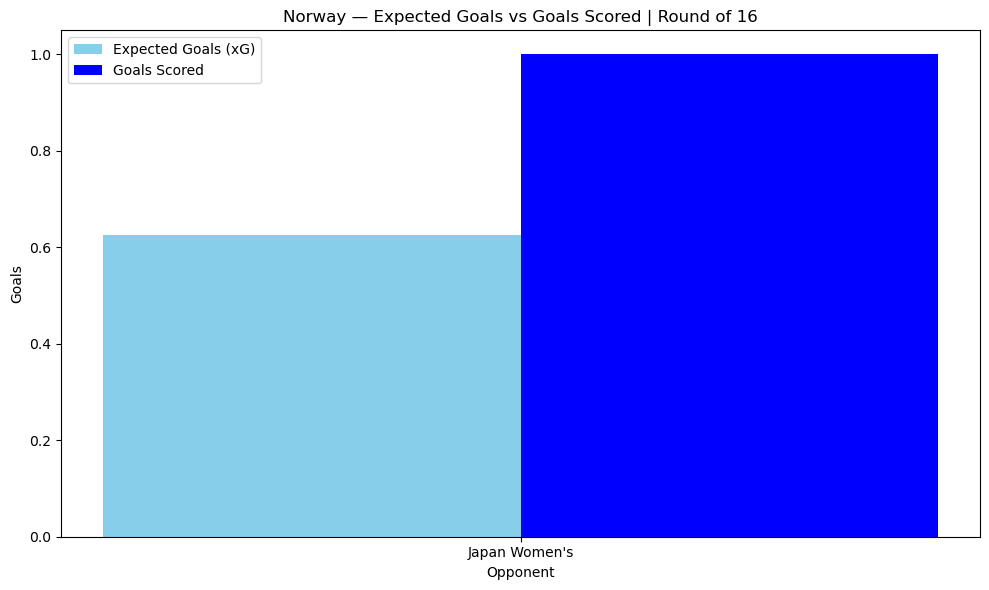

In [80]:
r16 = womens_world_cup_stats[
    (womens_world_cup_stats["team"] == "Norway Women's") &
    (womens_world_cup_stats["stage"] == "Round of 16")
].copy()

r16["match_date"] = pd.to_datetime(r16["match_date"])

r16 = r16.sort_values("match_date")

x = np.arange(len(r16))
width = 0.35

plt.figure(figsize=(10, 6))

plt.bar(
    x - width / 2,
    r16["xG"],
    width,
    label="Expected Goals (xG)",
    color="skyblue"
)

plt.bar(
    x + width / 2,
    r16["goals_for"],
    width,
    label="Goals Scored",
    color="blue"
)

plt.xticks(
    x,
    r16["opponent"]
)

plt.xlabel("Opponent")
plt.ylabel("Goals")
plt.title("Norway — Expected Goals vs Goals Scored | Round of 16")

plt.legend()

plt.tight_layout()
plt.show()

The charts above recreate something can be seen as the World Cup goes on: both of the teams are way more invested in these games rather than the group phase. Therefore, **the xG is bellow the actual soring result**, in both teams, which can be seen as higher performance.

In [114]:
match = womens_world_cup_stats[
    (
        (womens_world_cup_stats["team"] == "Japan Women's") &
        (womens_world_cup_stats["opponent"] == "Norway Women's")
    ) |
    (
        (womens_world_cup_stats["team"] == "Norway Women's") &
        (womens_world_cup_stats["opponent"] == "Japan Women's")
    )
].copy()


# Metrics to compare

metrics = {
    "Goals": "goals_for",
    "xG": "xG",
    "Goals Minus xG": "goals_minus_xG",
    "Shots": "shots",
    "Shots on Target": "shots_on_target",
    "Saves": "saves",
    "Possession %": "possession_pct",
    "Pass Accuracy %": "pass_accuracy_pct",
    "Progressive Passes": "progressive_passes",
    "Progressive Carries": "progressive_carries",
    "Final Third Entries": "final_third_entries",
    "Box Entries": "box_entries",
    "High Turnovers": "high_turnovers",
    "Tackles Won": "tackles_won",
    "Interceptions": "interceptions",
    "Blocks": "blocks",
    "Clearances": "clearances",
    "Recoveries": "recoveries", 
    "Goals from Shots": "goals_from_shots",
    "Own Goals From": "own_goals_for",	
    "Own Goals Against": "own_goals_against",	
    "Goal type": "goal_type"
}


# Create comparison table

comparison = pd.DataFrame({
    "Metric": metrics.keys(),

    "Japan": [
        match.loc[
            match["team"] == "Japan Women's", column
        ].iloc[0]
        for column in metrics.values()
    ],

    "Norway": [
        match.loc[
            match["team"] == "Norway Women's", column
        ].iloc[0]
        for column in metrics.values()
    ]
})


# Round selected metrics to 1 decimal place

decimal_metrics = [
    "xG",
    "Goals Minus xG",
    "Possession %",
    "Pass Accuracy %"
]

comparison.loc[
    comparison["Metric"].isin(decimal_metrics),
    ["Japan", "Norway"]
] = comparison.loc[
    comparison["Metric"].isin(decimal_metrics),
    ["Japan", "Norway"]
].round(1)


# Display table

comparison

,Metric,Japan,Norway
0,Goals,3,1
1,xG,0.983851,0.625605
2,Goals Minus xG,2.016149,0.374395
3,Shots,16,8
4,Shots on Target,4,3
5,Saves,2,2
6,Possession %,59.219881,40.780119
7,Pass Accuracy %,84.6875,76.431718
8,Progressive Passes,150.0,115.0
9,Progressive Carries,17.0,9.0


Teams found:
["Japan Women's" "Norway Women's"]


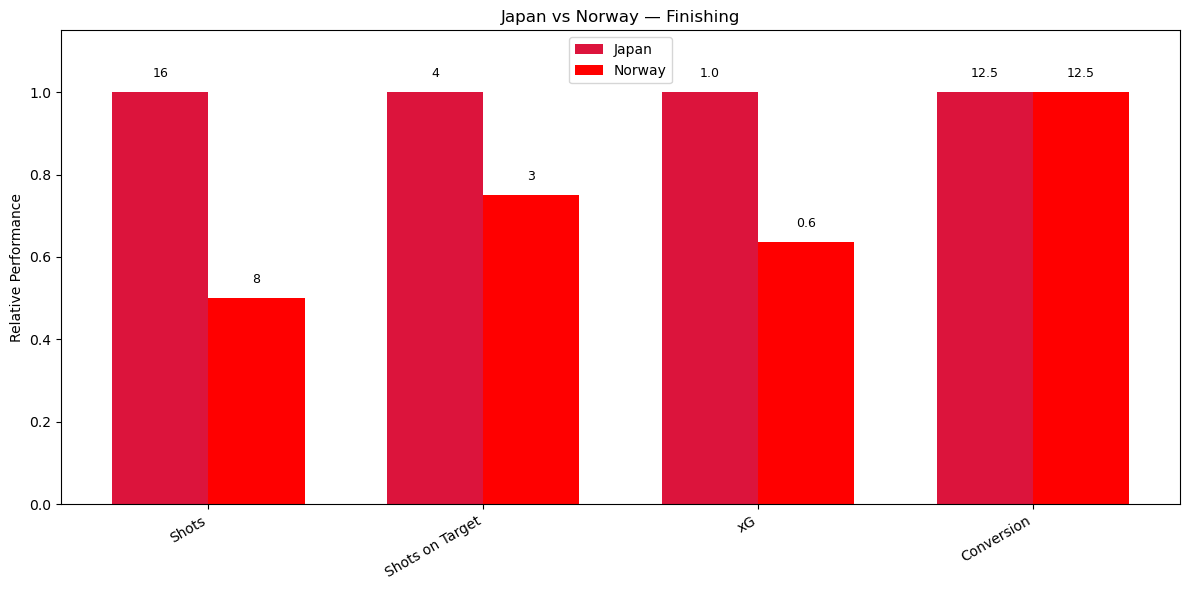

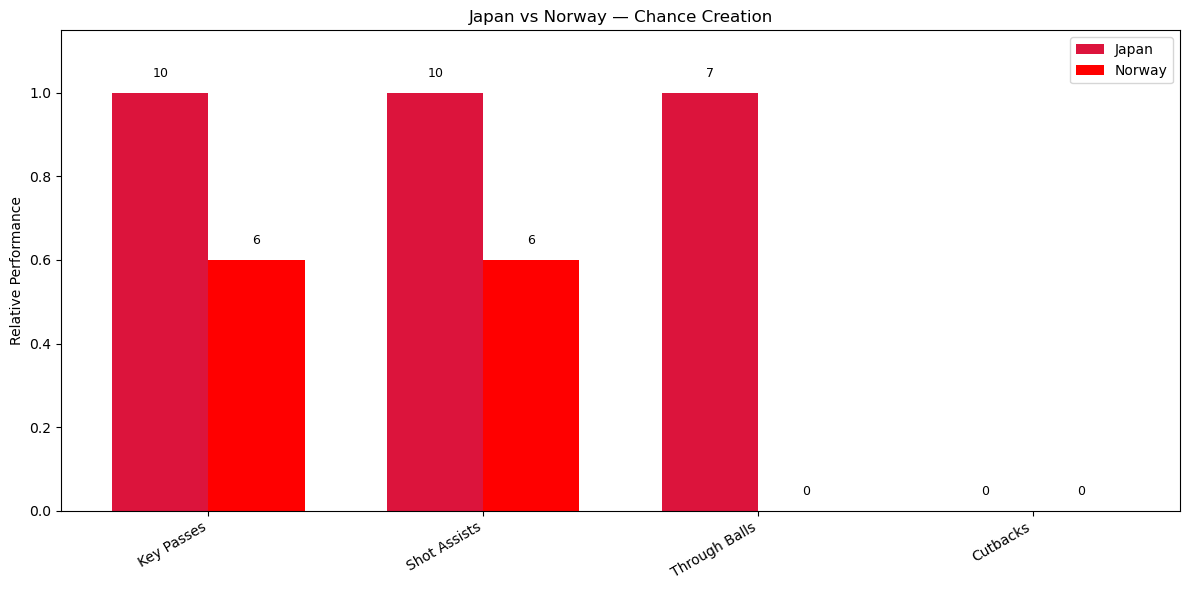

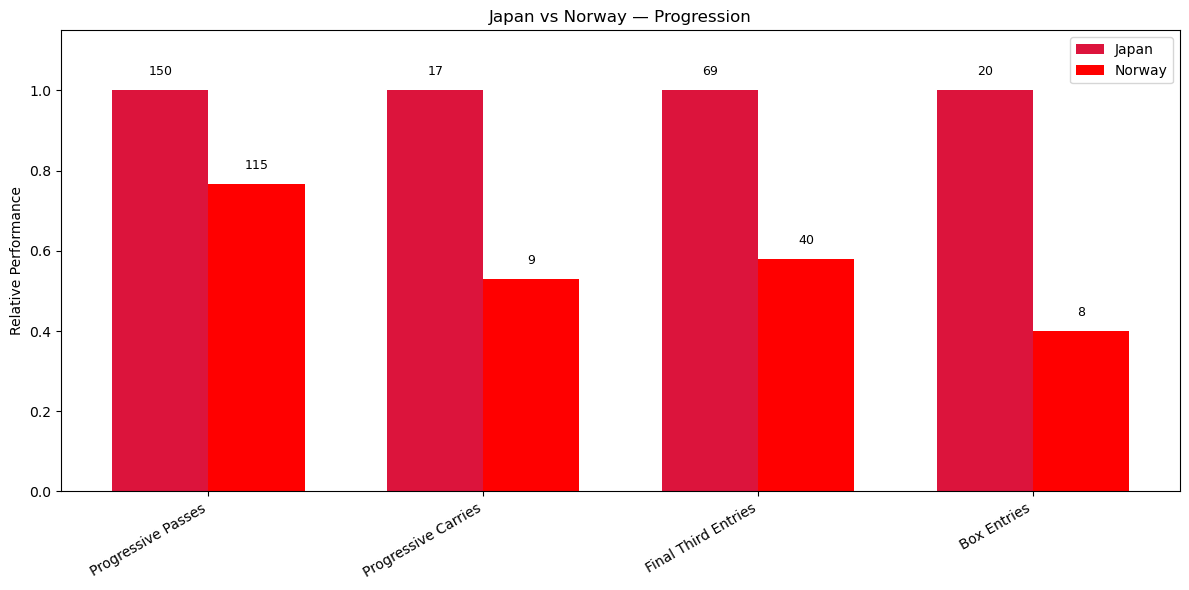

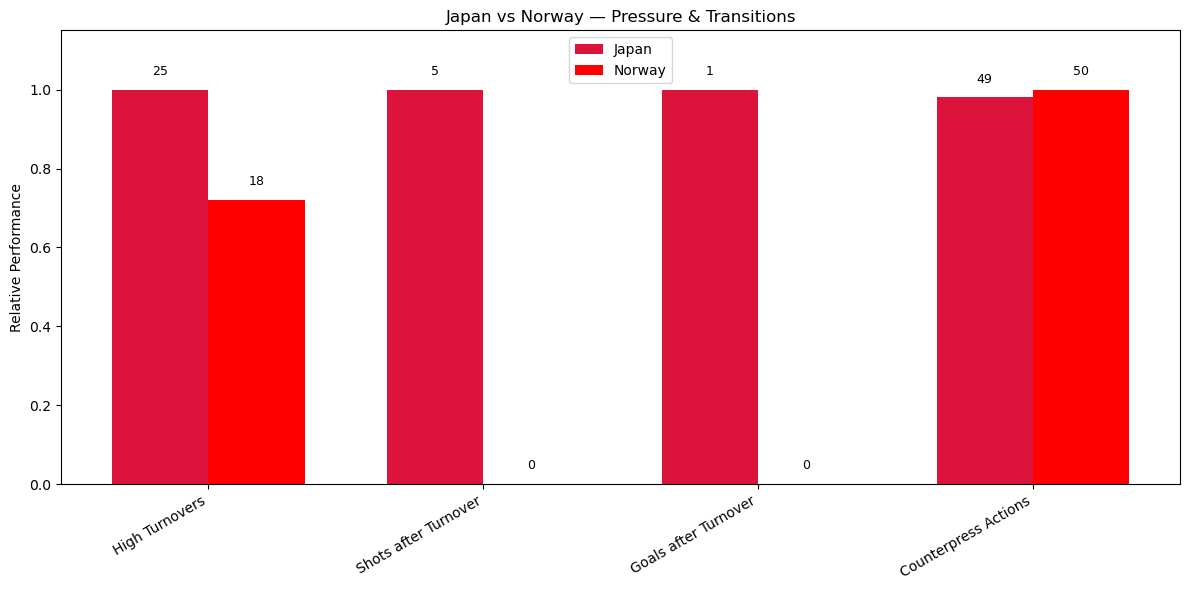

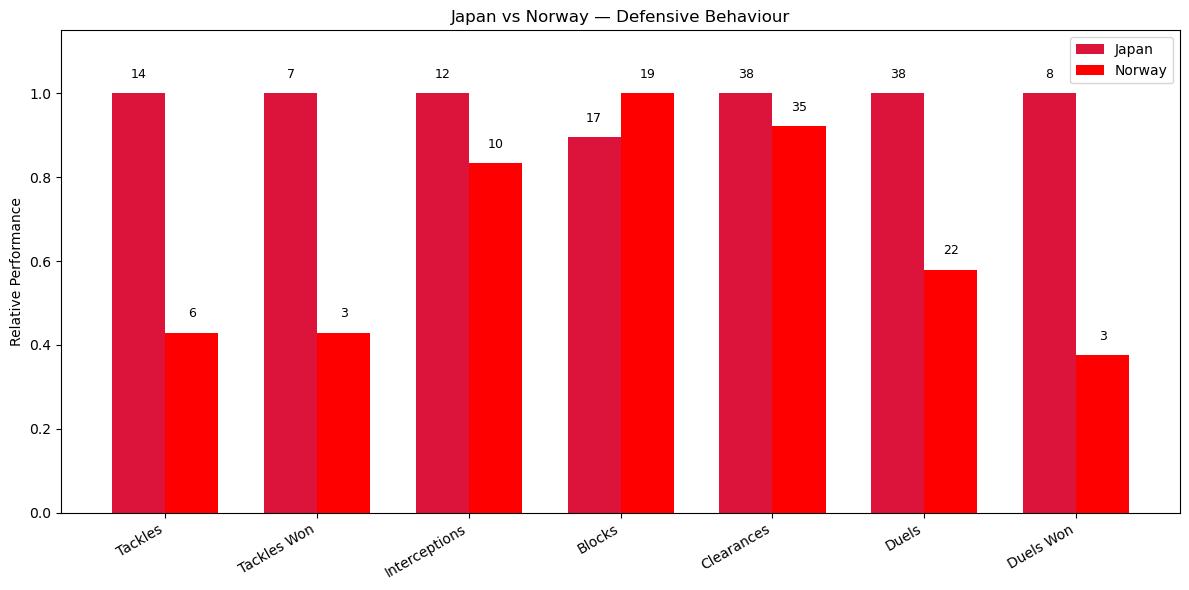

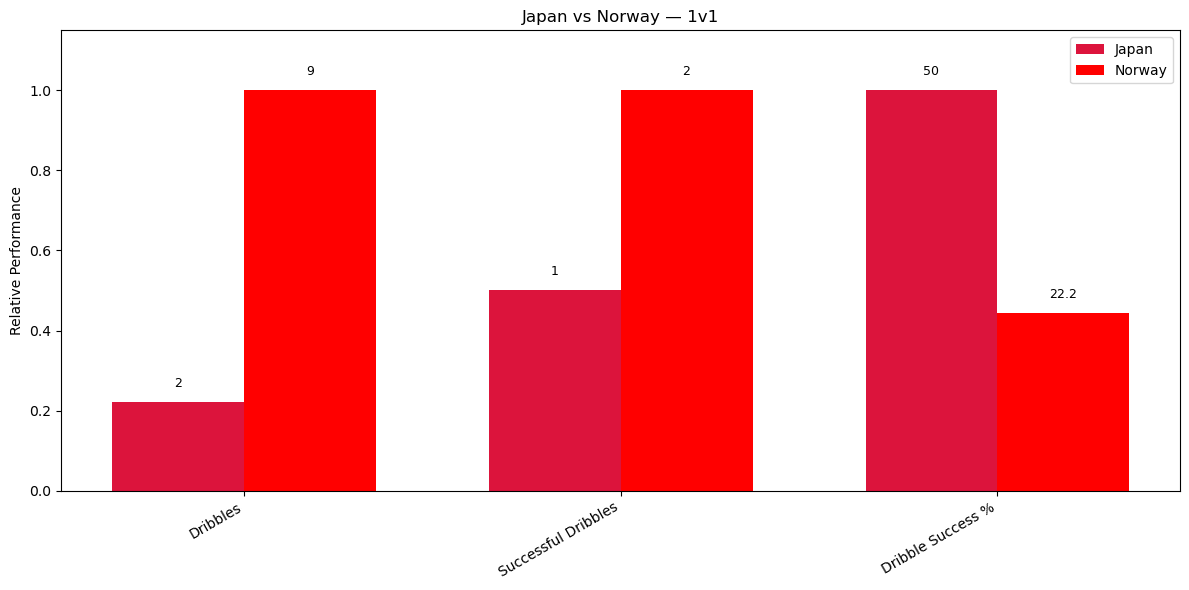

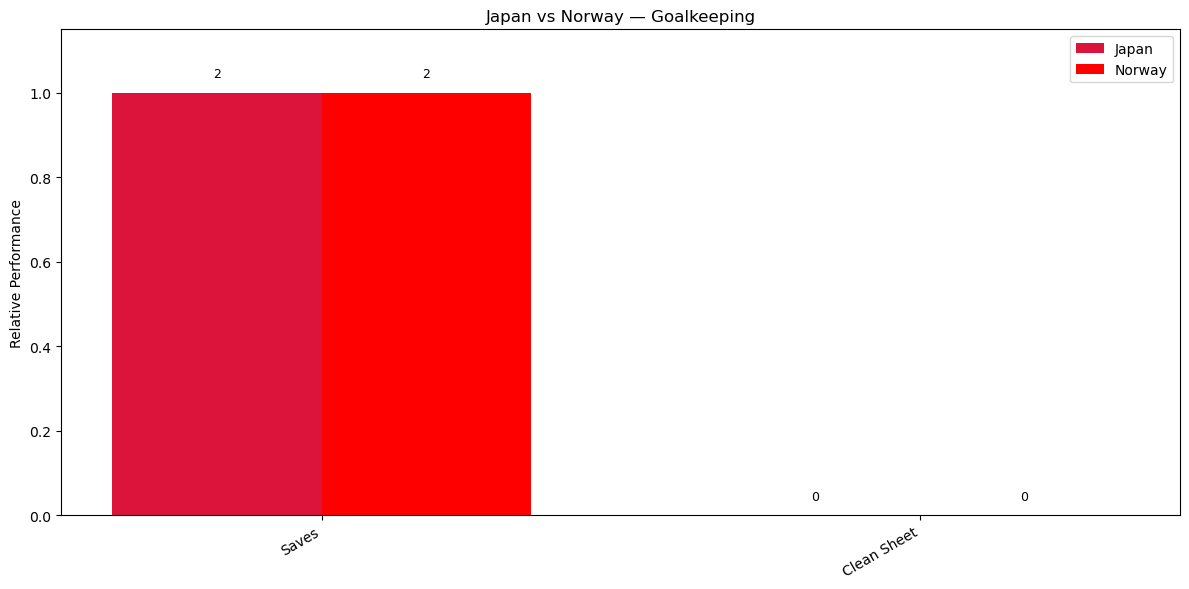

In [83]:
import matplotlib.pyplot as plt
import numpy as np


match = womens_world_cup_stats[
    (
        (
            (womens_world_cup_stats["team"] == "Japan Women's") &
            (womens_world_cup_stats["opponent"] == "Norway Women's")
        )
        |
        (
            (womens_world_cup_stats["team"] == "Norway Women's") &
            (womens_world_cup_stats["opponent"] == "Japan Women's")
        )
    )
    &
    (womens_world_cup_stats["stage"] == "Round of 16")
].copy()


# ============================================================
# 2. TEAM NAMES
# ============================================================

team_names = {
    "Japan": "Japan Women's",
    "Norway": "Norway Women's"
}


# ============================================================
# 3. METRICS BY CATEGORY
# ============================================================

categories = {


    "Finishing": {
        "Shots": "shots",
        "Shots on Target": "shots_on_target",
        "xG": "xG",
        "Conversion": "conversion_pct"
    },


     "Chance Creation": {
        "Key Passes": "key_passes",
        "Shot Assists": "shot_assists",
        "Through Balls": "through_balls",
        "Cutbacks": "cutbacks"
    },



    "Progression": {
        "Progressive Passes": "progressive_passes",
        "Progressive Carries": "progressive_carries",
        "Final Third Entries": "final_third_entries",
        "Box Entries": "box_entries"
    },



    "Pressure & Transitions": {
        "High Turnovers": "high_turnovers",
        "Shots after Turnover": "shots_after_turnover",
        "Goals after Turnover": "goals_after_turnover",
        "Counterpress Actions": "counterpress_actions"
    },



    "Defensive Behaviour": {
        "Tackles": "tackles",
        "Tackles Won": "tackles_won",
        "Interceptions": "interceptions",
        "Blocks": "blocks",
        "Clearances": "clearances",
        "Duels": "duels",
        "Duels Won": "duels_won"
    },



    "1v1": {
        "Dribbles": "dribbles",
        "Successful Dribbles": "successful_dribbles",
        "Dribble Success %": "dribble_success_pct"
    },



    "Goalkeeping": {
        "Saves": "saves",
        "Clean Sheet": "clean_sheet"
    }
}


# ============================================================
# 4. CHECK TEAMS
# ============================================================

print("Teams found:")
print(match["team"].unique())


# ============================================================
# 5. CREATE EACH CHART
# ============================================================

for category_name, metrics in categories.items():

    # --------------------------------------------------------
    # Get real values
    # --------------------------------------------------------

    jap_values = np.array([
        match.loc[
            match["team"] == team_names["Japan"],
            column
        ].iloc[0]
        for column in metrics.values()
    ], dtype=float)


    nor_values = np.array([
        match.loc[
            match["team"] == team_names["Norway"],
            column
        ].iloc[0]
        for column in metrics.values()
    ], dtype=float)


    # --------------------------------------------------------
    # Maximum value for each metric
    # --------------------------------------------------------

    max_values = np.maximum(
        jap_values,
        nor_values
    )


    # --------------------------------------------------------
    # Normalize
    # --------------------------------------------------------

    jap_normalized = np.divide(
        jap_values,
        max_values,
        out=np.zeros_like(jap_values),
        where=max_values != 0
    )


    nor_normalized = np.divide(
        nor_values,
        max_values,
        out=np.zeros_like(nor_values),
        where=max_values != 0
    )


    # --------------------------------------------------------
    # Position of bars
    # --------------------------------------------------------

    x = np.arange(len(metrics))
    width = 0.35


    # --------------------------------------------------------
    # Create figure
    # --------------------------------------------------------

    plt.figure(figsize=(12, 6))


    bars_jap = plt.bar(
        x - width / 2,
        jap_normalized,
        width,
        label="Japan",
        color="Crimson"
    )


    bars_nor = plt.bar(
        x + width / 2,
        nor_normalized,
        width,
        label="Norway",
        color="red"
    )


    # ========================================================
    # REAL VALUES ABOVE BARS
    # ========================================================

    for bar, value in zip(
        bars_jap,
        jap_values
    ):

        if value.is_integer():
            label = f"{int(value)}"
        else:
            label = f"{value:.1f}"

        plt.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.03,
            label,
            ha="center",
            va="bottom",
            fontsize=9
        )


    for bar, value in zip(
        bars_nor,
        nor_values
    ):

        if value.is_integer():
            label = f"{int(value)}"
        else:
            label = f"{value:.1f}"

        plt.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.03,
            label,
            ha="center",
            va="bottom",
            fontsize=9
        )


    # ========================================================
    # LABELS
    # ========================================================

    plt.xticks(
        x,
        metrics.keys(),
        rotation=30,
        ha="right"
    )

    plt.ylabel("Relative Performance")

    plt.title(
        f"Japan vs Norway — {category_name}"
    )

    plt.ylim(0, 1.15)

    plt.legend()

    plt.tight_layout()

    plt.show()

In [107]:
match[[
    "team",
    "opponent",
    "formation"
]]

,team,opponent,formation
98,Japan Women's,Norway Women's,3-4-2-1
99,Norway Women's,Japan Women's,4-1-4-1


In [109]:
formation_comparison = pd.DataFrame({
    "Metric": [
        "Formation",
        "Possession %",
        "Shots",
        "xG",
        "Progressive Passes",
        "Progressive Carries",
        "Final Third Entries",
        "Box Entries",
        "High Turnovers",
        "Interceptions",
        "Clearances"
    ],

    "Japan": [
        match.loc[
            match["team"] == "Japan Women's",
            "formation"
        ].iloc[0],
        
        match.loc[
            match["team"] == "Japan Women's",
            "possession_pct"
        ].iloc[0],
        
        match.loc[
            match["team"] == "Japan Women's",
            "shots"
        ].iloc[0],
        
        match.loc[
            match["team"] == "Japan Women's",
            "xG"
        ].iloc[0],
        
        match.loc[
            match["team"] == "Japan Women's",
            "progressive_passes"
        ].iloc[0],
        
        match.loc[
            match["team"] == "Japan Women's",
            "progressive_carries"
        ].iloc[0],
        
        match.loc[
            match["team"] == "Japan Women's",
            "final_third_entries"
        ].iloc[0],
        
        match.loc[
            match["team"] == "Japan Women's",
            "box_entries"
        ].iloc[0],
        
        match.loc[
            match["team"] == "Japan Women's",
            "high_turnovers"
        ].iloc[0],
        
        match.loc[
            match["team"] == "Japan Women's",
            "interceptions"
        ].iloc[0],
        
        match.loc[
            match["team"] == "Japan Women's",
            "clearances"
        ].iloc[0]
    ],

    "Norway": [
        match.loc[
            match["team"] == "Norway Women's",
            "formation"
        ].iloc[0],
        
        match.loc[
            match["team"] == "Norway Women's",
            "possession_pct"
        ].iloc[0],
        
        match.loc[
            match["team"] == "Norway Women's",
            "shots"
        ].iloc[0],
        
        match.loc[
            match["team"] == "Norway Women's",
            "xG"
        ].iloc[0],
        
        match.loc[
            match["team"] == "Norway Women's",
            "progressive_passes"
        ].iloc[0],
        
        match.loc[
            match["team"] == "Norway Women's",
            "progressive_carries"
        ].iloc[0],
        
        match.loc[
            match["team"] == "Norway Women's",
            "final_third_entries"
        ].iloc[0],
        
        match.loc[
            match["team"] == "Norway Women's",
            "box_entries"
        ].iloc[0],
        
        match.loc[
            match["team"] == "Norway Women's",
            "high_turnovers"
        ].iloc[0],
        
        match.loc[
            match["team"] == "Norway Women's",
            "interceptions"
        ].iloc[0],
        
        match.loc[
            match["team"] == "Norway Women's",
            "clearances"
        ].iloc[0]
    ]
})

# Arredondar percentagens e xG
formation_comparison.loc[
    formation_comparison["Metric"].isin(
        ["Possession %", "xG"]
    ),
    ["Japan", "Norway"]
] = formation_comparison.loc[
    formation_comparison["Metric"].isin(
        ["Possession %", "xG"]
    ),
    ["Japan", "Norway"]
].round(1)

formation_comparison

,Metric,Japan,Norway
0,Formation,3-4-2-1,4-1-4-1
1,Possession %,59.219881,40.780119
2,Shots,16,8
3,xG,0.983851,0.625605
4,Progressive Passes,150.0,115.0
5,Progressive Carries,17.0,9.0
6,Final Third Entries,69.0,40.0
7,Box Entries,20.0,8.0
8,High Turnovers,25.0,18.0
9,Interceptions,12,10


## Conclusion JAP-NOR

Japan completely dominated Norway, recording **higher values across almost all of the analysed metrics**. The team showed a clear strategy to maintain a balanced approach while consistently operating within a 3-4-2-1 formation. In contrast, Norway adopted a much more defensive approach, with some notable moments in terms of pressing and 1v1 duels. However, given their more defensive distribution, higher defensive metrics would have been expected. This was not necessarily reflected in the data, as Norway did not show a clear defensive advantage in most of these metrics. Furthermore, the own goal conceded by Norway also contributed to the final outcome, highlighting the difficulties they faced when dealing with Japan’s overall dominance.

# GAME ANALYSIS NED-RSA

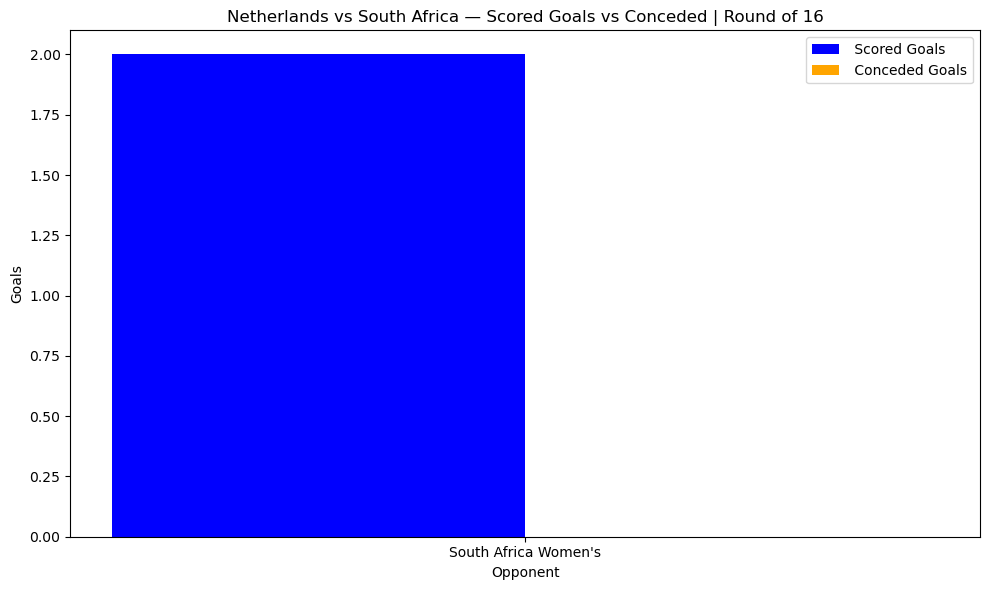

In [119]:
r16 = womens_world_cup_stats[
    (womens_world_cup_stats["team"] == "Netherlands Women's") &
    (womens_world_cup_stats["stage"] == "Round of 16")
].copy()

r16["match_date"] = pd.to_datetime(r16["match_date"])

r16 = r16.sort_values("match_date")

x = np.arange(len(r16))
width = 0.35

plt.figure(figsize=(10, 6))

plt.bar(
    x - width / 2,
    r16["goals_for"],
    width,
    label=" Scored Goals",
    color = "blue"
)

plt.bar(
    x + width / 2,
    r16["goals_against"],
    width,
    label= " Conceded Goals",
    color = "orange"
)

plt.xticks(
    x,
    r16["opponent"]
)

plt.xlabel("Opponent")
plt.ylabel("Goals")
plt.title("Netherlands vs South Africa — Scored Goals vs Conceded | Round of 16")

plt.legend()

plt.tight_layout()
plt.show()

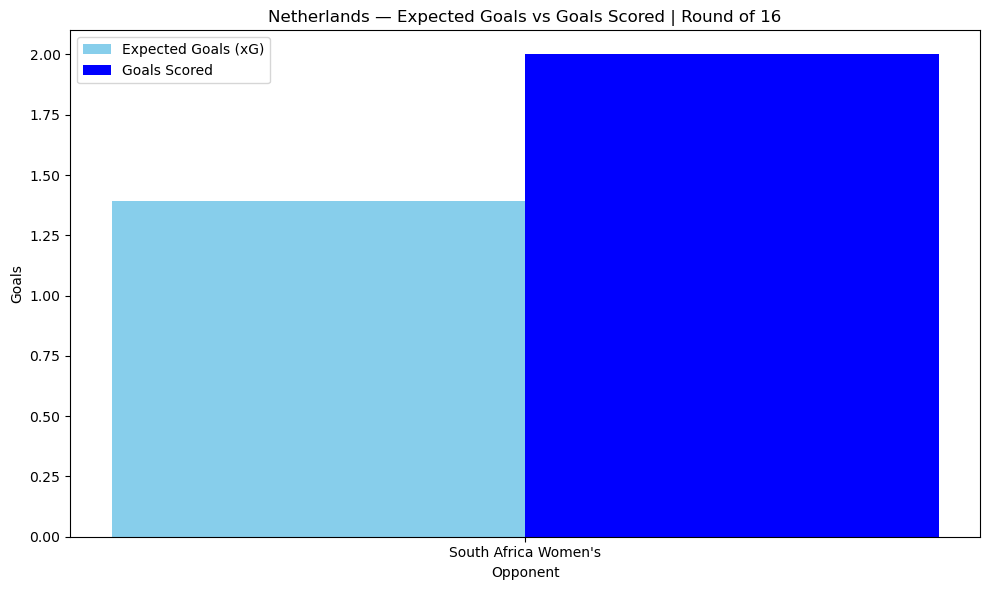

In [121]:
r16 = womens_world_cup_stats[
    (womens_world_cup_stats["team"] == "Netherlands Women's") &
    (womens_world_cup_stats["stage"] == "Round of 16")
].copy()

r16["match_date"] = pd.to_datetime(r16["match_date"])

r16 = r16.sort_values("match_date")

x = np.arange(len(r16))
width = 0.35

plt.figure(figsize=(10, 6))

plt.bar(
    x - width / 2,
    r16["xG"],
    width,
    label="Expected Goals (xG)",
    color="skyblue"
)

plt.bar(
    x + width / 2,
    r16["goals_for"],
    width,
    label="Goals Scored",
    color="blue"
)

plt.xticks(
    x,
    r16["opponent"]
)

plt.xlabel("Opponent")
plt.ylabel("Goals")
plt.title("Netherlands — Expected Goals vs Goals Scored | Round of 16")

plt.legend()

plt.tight_layout()
plt.show()

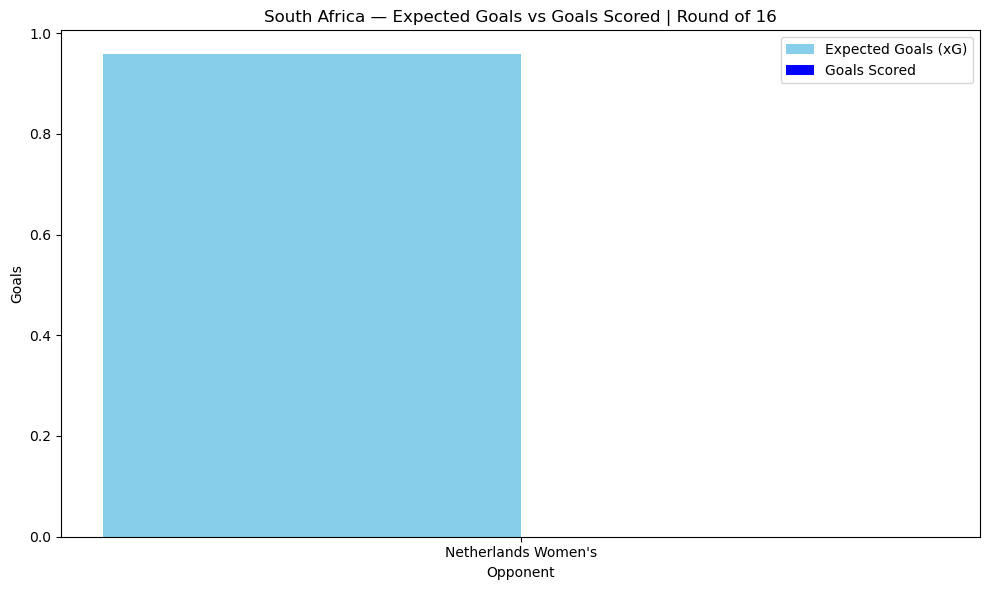

In [123]:
r16 = womens_world_cup_stats[
    (womens_world_cup_stats["team"] == "South Africa Women's") &
    (womens_world_cup_stats["stage"] == "Round of 16")
].copy()

r16["match_date"] = pd.to_datetime(r16["match_date"])

r16 = r16.sort_values("match_date")

x = np.arange(len(r16))
width = 0.35

plt.figure(figsize=(10, 6))

plt.bar(
    x - width / 2,
    r16["xG"],
    width,
    label="Expected Goals (xG)",
    color="skyblue"
)

plt.bar(
    x + width / 2,
    r16["goals_for"],
    width,
    label="Goals Scored",
    color="blue"
)

plt.xticks(
    x,
    r16["opponent"]
)

plt.xlabel("Opponent")
plt.ylabel("Goals")
plt.title("South Africa — Expected Goals vs Goals Scored | Round of 16")

plt.legend()

plt.tight_layout()
plt.show()

In [125]:
match = womens_world_cup_stats[
    (
        (womens_world_cup_stats["team"] == "Netherlands Women's") &
        (womens_world_cup_stats["opponent"] == "South Africa Women's")
    ) |
    (
        (womens_world_cup_stats["team"] == "South Africa Women's") &
        (womens_world_cup_stats["opponent"] == "Netherlands Women's")
    )
].copy()


# Metrics to compare

metrics = {
    "Goals": "goals_for",
    "xG": "xG",
    "Goals Minus xG": "goals_minus_xG",
    "Shots": "shots",
    "Shots on Target": "shots_on_target",
    "Saves": "saves",
    "Possession %": "possession_pct",
    "Pass Accuracy %": "pass_accuracy_pct",
    "Progressive Passes": "progressive_passes",
    "Progressive Carries": "progressive_carries",
    "Final Third Entries": "final_third_entries",
    "Box Entries": "box_entries",
    "High Turnovers": "high_turnovers",
    "Tackles Won": "tackles_won",
    "Interceptions": "interceptions",
    "Blocks": "blocks",
    "Clearances": "clearances",
    "Recoveries": "recoveries", 
    "Goals from Shots": "goals_from_shots",
    "Own Goals From": "own_goals_for",	
    "Own Goals Against": "own_goals_against",	
    "Goal type": "goal_type"
}


# Create comparison table

comparison = pd.DataFrame({
    "Metric": metrics.keys(),

    "Netherlands": [
        match.loc[
            match["team"] == "Netherlands Women's", column
        ].iloc[0]
        for column in metrics.values()
    ],

    "South Africa": [
        match.loc[
            match["team"] == "South Africa Women's", column
        ].iloc[0]
        for column in metrics.values()
    ]
})


# Round selected metrics to 1 decimal place

decimal_metrics = [
    "xG",
    "Goals Minus xG",
    "Possession %",
    "Pass Accuracy %"
]

comparison.loc[
    comparison["Metric"].isin(decimal_metrics),
    ["Netherlands", "South Africa"]
] = comparison.loc[
    comparison["Metric"].isin(decimal_metrics),
    ["Netherlands", "South Africa"]
].round(1)


# Display table

comparison

,Metric,Netherlands,South Africa
0,Goals,2,0
1,xG,1.393599,0.957485
2,Goals Minus xG,0.606401,-0.957485
3,Shots,12,14
4,Shots on Target,6,8
5,Saves,8,4
6,Possession %,70.75706,29.24294
7,Pass Accuracy %,82.047686,61.437908
8,Progressive Passes,162.0,82.0
9,Progressive Carries,24.0,16.0


Teams found:
["Netherlands Women's" "South Africa Women's"]


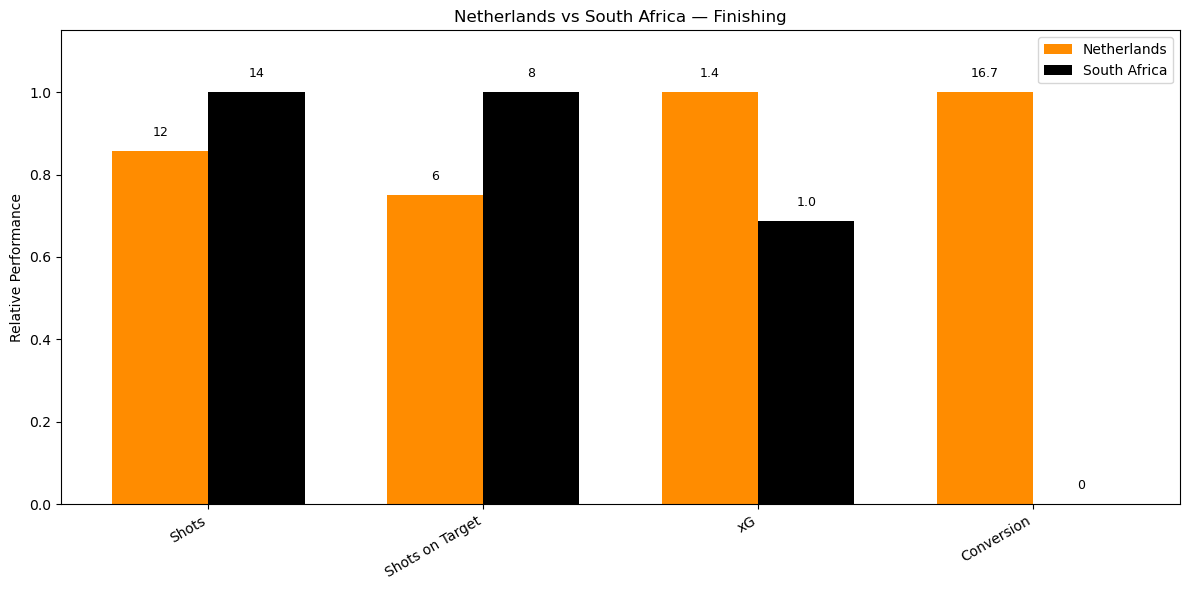

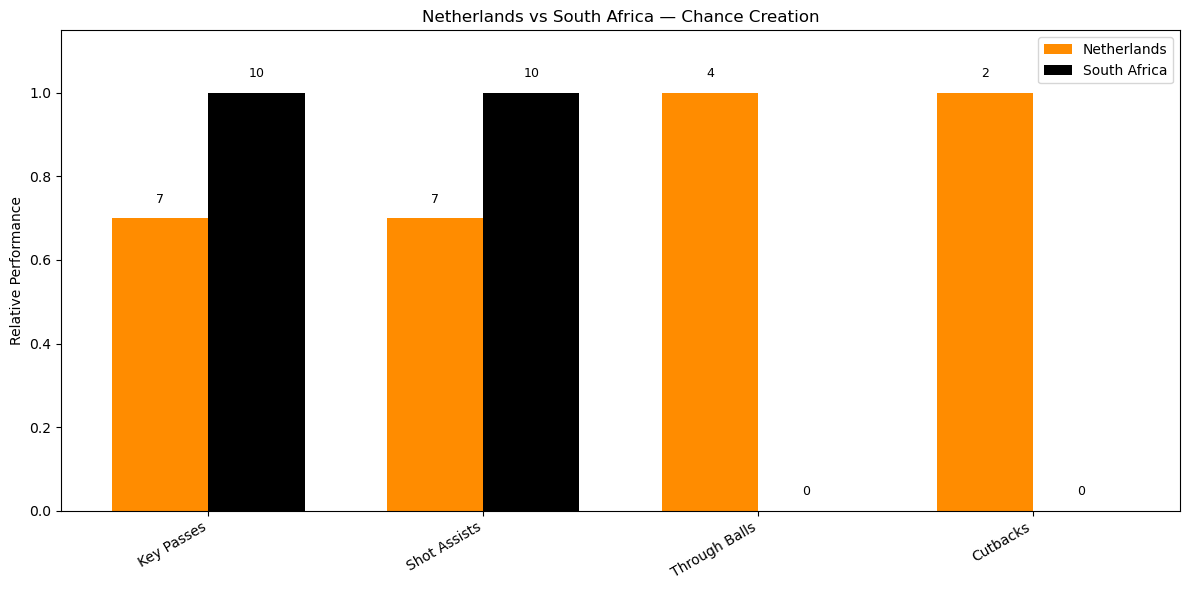

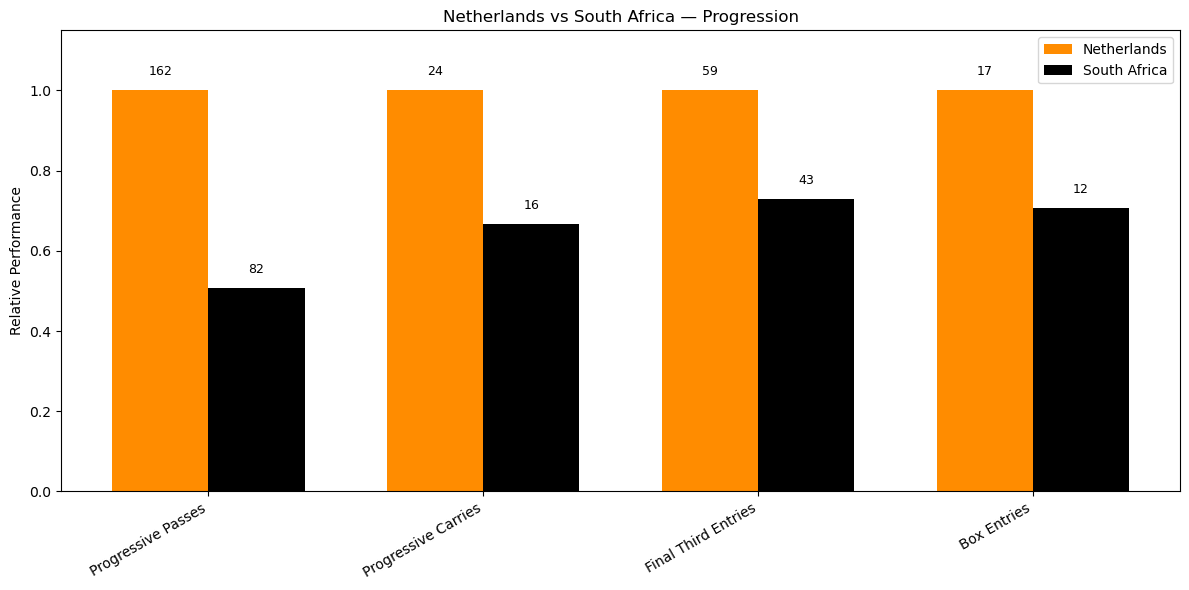

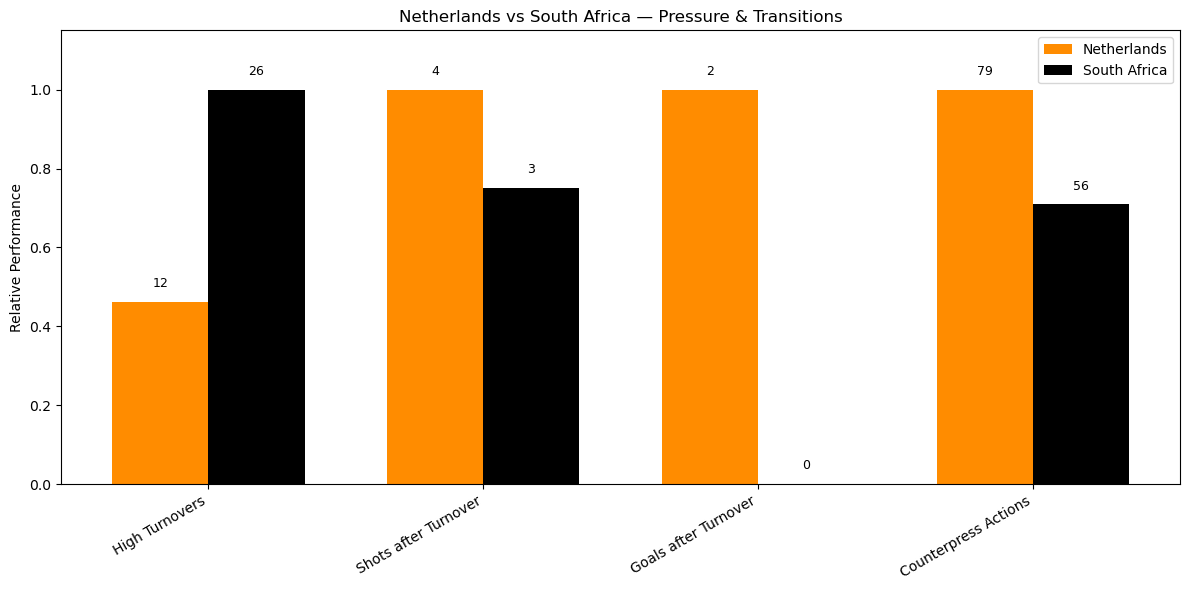

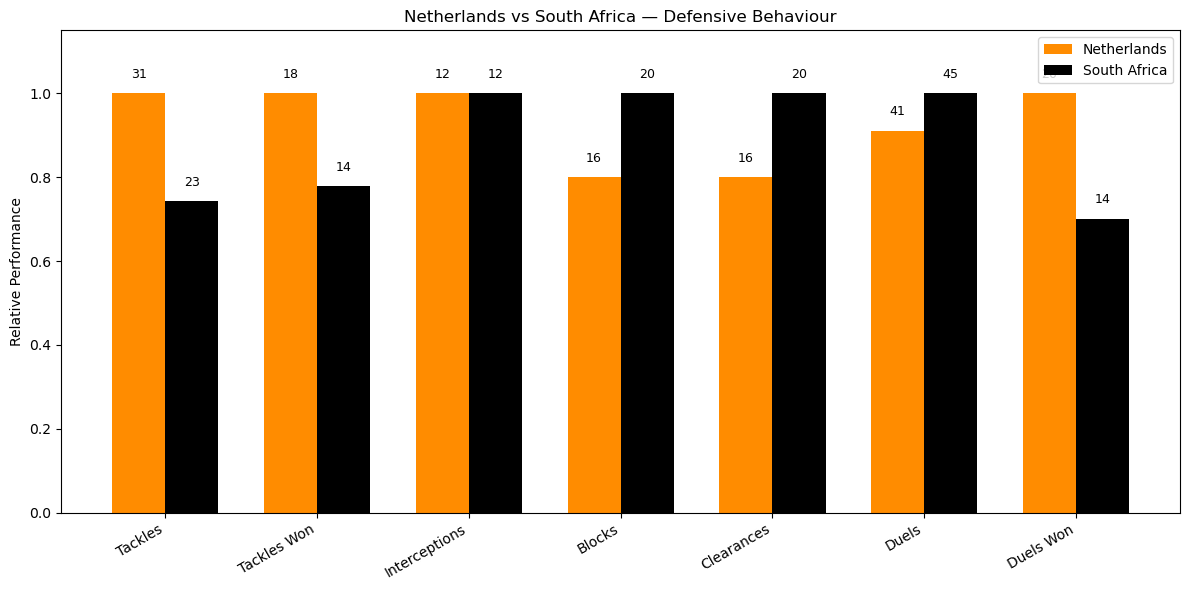

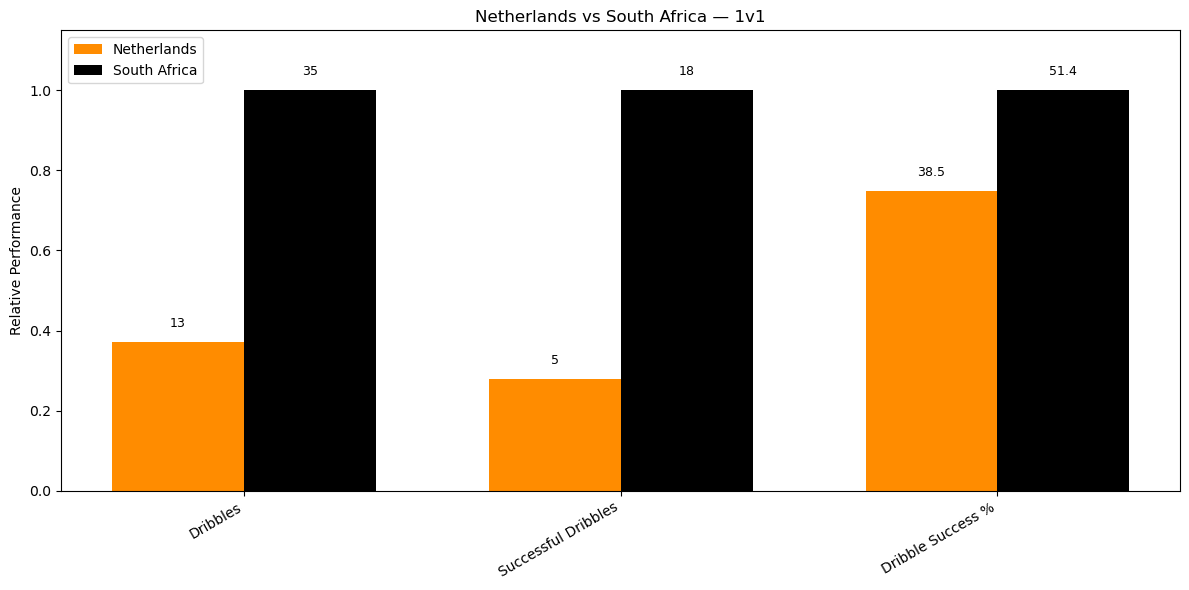

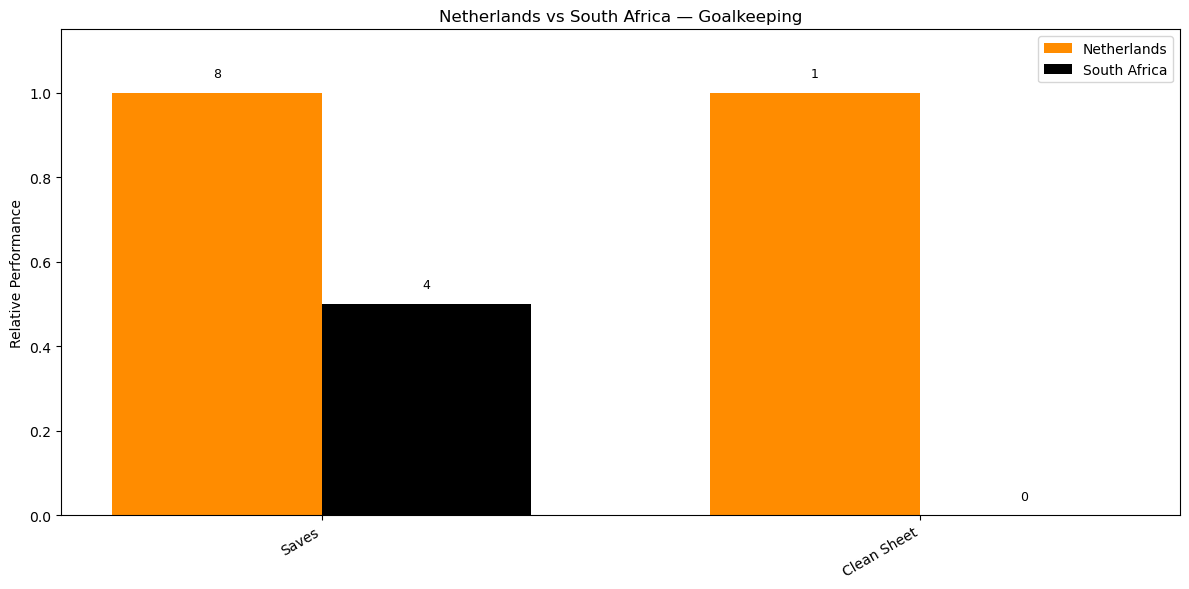

In [127]:
import matplotlib.pyplot as plt
import numpy as np


match = womens_world_cup_stats[
    (
        (womens_world_cup_stats["team"] == "Netherlands Women's") &
        (womens_world_cup_stats["opponent"] == "South Africa Women's")
    ) |
    (
        (womens_world_cup_stats["team"] == "South Africa Women's") &
        (womens_world_cup_stats["opponent"] == "Netherlands Women's")
    )
    &
    (womens_world_cup_stats["stage"] == "Round of 16")
].copy()


# ============================================================
# 2. TEAM NAMES
# ============================================================

team_names = {
    "Netherlands": "Netherlands Women's",
    "South Africa": "South Africa Women's"
}


# ============================================================
# 3. METRICS BY CATEGORY
# ============================================================

categories = {


    "Finishing": {
        "Shots": "shots",
        "Shots on Target": "shots_on_target",
        "xG": "xG",
        "Conversion": "conversion_pct"
    },


     "Chance Creation": {
        "Key Passes": "key_passes",
        "Shot Assists": "shot_assists",
        "Through Balls": "through_balls",
        "Cutbacks": "cutbacks"
    },



    "Progression": {
        "Progressive Passes": "progressive_passes",
        "Progressive Carries": "progressive_carries",
        "Final Third Entries": "final_third_entries",
        "Box Entries": "box_entries"
    },



    "Pressure & Transitions": {
        "High Turnovers": "high_turnovers",
        "Shots after Turnover": "shots_after_turnover",
        "Goals after Turnover": "goals_after_turnover",
        "Counterpress Actions": "counterpress_actions"
    },



    "Defensive Behaviour": {
        "Tackles": "tackles",
        "Tackles Won": "tackles_won",
        "Interceptions": "interceptions",
        "Blocks": "blocks",
        "Clearances": "clearances",
        "Duels": "duels",
        "Duels Won": "duels_won"
    },



    "1v1": {
        "Dribbles": "dribbles",
        "Successful Dribbles": "successful_dribbles",
        "Dribble Success %": "dribble_success_pct"
    },



    "Goalkeeping": {
        "Saves": "saves",
        "Clean Sheet": "clean_sheet"
    }
}


# ============================================================
# 4. CHECK TEAMS
# ============================================================

print("Teams found:")
print(match["team"].unique())


# ============================================================
# 5. CREATE EACH CHART
# ============================================================

for category_name, metrics in categories.items():

    # --------------------------------------------------------
    # Get real values
    # --------------------------------------------------------

    ned_values = np.array([
        match.loc[
            match["team"] == team_names["Netherlands"],
            column
        ].iloc[0]
        for column in metrics.values()
    ], dtype=float)


    rsa_values = np.array([
        match.loc[
            match["team"] == team_names["South Africa"],
            column
        ].iloc[0]
        for column in metrics.values()
    ], dtype=float)


    # --------------------------------------------------------
    # Maximum value for each metric
    # --------------------------------------------------------

    max_values = np.maximum(
        ned_values,
        rsa_values
    )


    # --------------------------------------------------------
    # Normalize
    # --------------------------------------------------------

    ned_normalized = np.divide(
        ned_values,
        max_values,
        out=np.zeros_like(ned_values),
        where=max_values != 0
    )


    rsa_normalized = np.divide(
        rsa_values,
        max_values,
        out=np.zeros_like(rsa_values),
        where=max_values != 0
    )


    # --------------------------------------------------------
    # Position of bars
    # --------------------------------------------------------

    x = np.arange(len(metrics))
    width = 0.35


    # --------------------------------------------------------
    # Create figure
    # --------------------------------------------------------

    plt.figure(figsize=(12, 6))


    bars_ned = plt.bar(
        x - width / 2,
        ned_normalized,
        width,
        label="Netherlands",
        color="darkorange"
    )


    bars_rsa = plt.bar(
        x + width / 2,
        rsa_normalized,
        width,
        label="South Africa",
        color="black"
    )


    # ========================================================
    # REAL VALUES ABOVE BARS
    # ========================================================

    for bar, value in zip(
        bars_ned,
        ned_values
    ):

        if value.is_integer():
            label = f"{int(value)}"
        else:
            label = f"{value:.1f}"

        plt.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.03,
            label,
            ha="center",
            va="bottom",
            fontsize=9
        )


    for bar, value in zip(
        bars_rsa,
        rsa_values
    ):

        if value.is_integer():
            label = f"{int(value)}"
        else:
            label = f"{value:.1f}"

        plt.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.03,
            label,
            ha="center",
            va="bottom",
            fontsize=9
        )


    # ========================================================
    # LABELS
    # ========================================================

    plt.xticks(
        x,
        metrics.keys(),
        rotation=30,
        ha="right"
    )

    plt.ylabel("Relative Performance")

    plt.title(
        f"Netherlands vs South Africa — {category_name}"
    )

    plt.ylim(0, 1.15)

    plt.legend()

    plt.tight_layout()

    plt.show()

In [129]:
match[[
    "team",
    "opponent",
    "formation"
]]

,team,opponent,formation
100,Netherlands Women's,South Africa Women's,3-5-2
101,South Africa Women's,Netherlands Women's,4-2-3-1


In [139]:
formation_comparison = pd.DataFrame({
    "Metric": [
        "Formation",
        "Possession %",
        "Shots",
        "xG",
        "Progressive Passes",
        "Progressive Carries",
        "Final Third Entries",
        "Box Entries",
        "High Turnovers",
        "Interceptions",
        "Clearances"
    ],

    "Netherlands": [
        match.loc[
            match["team"] == "Netherlands Women's",
            "formation"
        ].iloc[0],
        
        match.loc[
            match["team"] == "Netherlands Women's",
            "possession_pct"
        ].iloc[0],
        
        match.loc[
            match["team"] == "Netherlands Women's",
            "shots"
        ].iloc[0],
        
        match.loc[
            match["team"] == "Netherlands Women's",
            "xG"
        ].iloc[0],
        
        match.loc[
            match["team"] == "Netherlands Women's",
            "progressive_passes"
        ].iloc[0],
        
        match.loc[
            match["team"] == "Netherlands Women's",
            "progressive_carries"
        ].iloc[0],
        
        match.loc[
            match["team"] == "Netherlands Women's",
            "final_third_entries"
        ].iloc[0],
        
        match.loc[
            match["team"] == "Netherlands Women's",
            "box_entries"
        ].iloc[0],
        
        match.loc[
            match["team"] == "Netherlands Women's",
            "high_turnovers"
        ].iloc[0],
        
        match.loc[
            match["team"] == "Netherlands Women's",
            "interceptions"
        ].iloc[0],
        
        match.loc[
            match["team"] == "Netherlands Women's",
            "clearances"
        ].iloc[0]
    ],

    "South Africa": [
        match.loc[
            match["team"] == "South Africa Women's",
            "formation"
        ].iloc[0],
        
        match.loc[
            match["team"] == "South Africa Women's",
            "possession_pct"
        ].iloc[0],
        
        match.loc[
            match["team"] == "South Africa Women's",
            "shots"
        ].iloc[0],
        
        match.loc[
            match["team"] == "South Africa Women's",
            "xG"
        ].iloc[0],
        
        match.loc[
            match["team"] == "South Africa Women's",
            "progressive_passes"
        ].iloc[0],
        
        match.loc[
            match["team"] == "South Africa Women's",
            "progressive_carries"
        ].iloc[0],
        
        match.loc[
            match["team"] == "South Africa Women's",
            "final_third_entries"
        ].iloc[0],
        
        match.loc[
            match["team"] == "South Africa Women's",
            "box_entries"
        ].iloc[0],
        
        match.loc[
            match["team"] == "South Africa Women's",
            "high_turnovers"
        ].iloc[0],
        
        match.loc[
            match["team"] == "South Africa Women's",
            "interceptions"
        ].iloc[0],
        
        match.loc[
            match["team"] == "South Africa Women's",
            "clearances"
        ].iloc[0]
    ]
})

# Arredondar percentagens e xG
formation_comparison.loc[
    formation_comparison["Metric"].isin(
        ["Possession %", "xG"]
    ),
    ["Netherlands", "South Africa"]
] = formation_comparison.loc[
    formation_comparison["Metric"].isin(
        ["Possession %", "xG"]
    ),
    ["Netherlands", "South Africa"]
].round(1)

formation_comparison

,Metric,Netherlands,South Africa
0,Formation,3-5-2,4-2-3-1
1,Possession %,70.75706,29.24294
2,Shots,12,14
3,xG,1.393599,0.957485
4,Progressive Passes,162.0,82.0
5,Progressive Carries,24.0,16.0
6,Final Third Entries,59.0,43.0
7,Box Entries,17.0,12.0
8,High Turnovers,12.0,26.0
9,Interceptions,12,12


## Conclusion NED-RSA

This was a relatively balanced game, with different strengths from both teams. The Netherlands were stronger in possession and progression, with their 3-5-2 supporting their attacking structure. South Africa, using a 4-2-3-1, showed greater defensive intensity and created more shooting opportunities.

However, South Africa failed to convert their chances, despite recording 8 shots on target and 0.96 xG. The Netherlands’ two goals from 1.39 xG highlight their greater finishing efficiency, as well as their defensive ability to prevent South Africa from scoring.

# GAME ANALYSIS SWE-USA

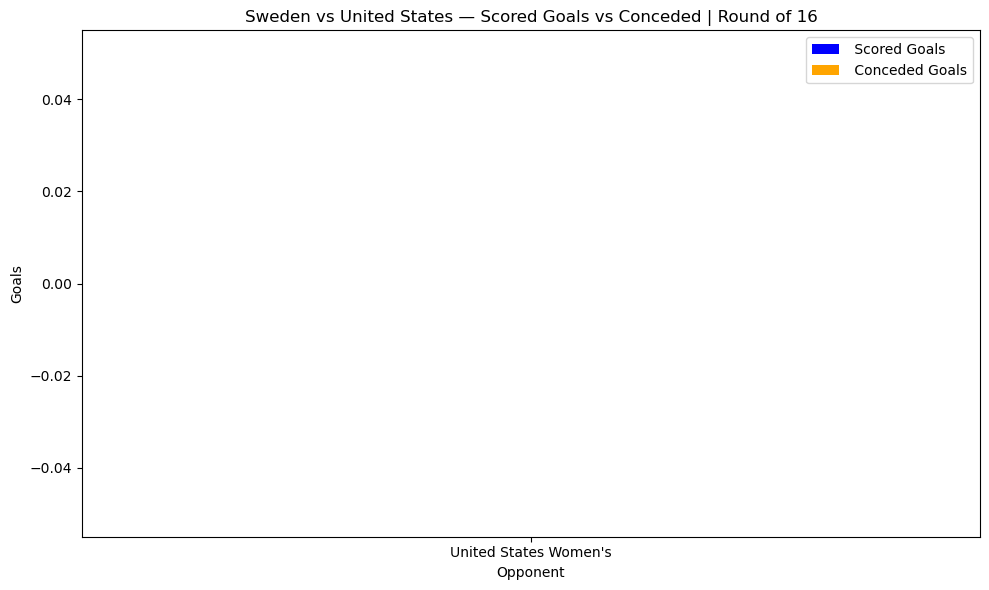

In [144]:
r16 = womens_world_cup_stats[
    (womens_world_cup_stats["team"] == "Sweden Women's") &
    (womens_world_cup_stats["stage"] == "Round of 16")
].copy()

r16["match_date"] = pd.to_datetime(r16["match_date"])

r16 = r16.sort_values("match_date")

x = np.arange(len(r16))
width = 0.35

plt.figure(figsize=(10, 6))

plt.bar(
    x - width / 2,
    r16["goals_for"],
    width,
    label=" Scored Goals",
    color = "blue"
)

plt.bar(
    x + width / 2,
    r16["goals_against"],
    width,
    label= " Conceded Goals",
    color = "orange"
)

plt.xticks(
    x,
    r16["opponent"]
)

plt.xlabel("Opponent")
plt.ylabel("Goals")
plt.title("Sweden vs United States — Scored Goals vs Conceded | Round of 16")

plt.legend()

plt.tight_layout()
plt.show()

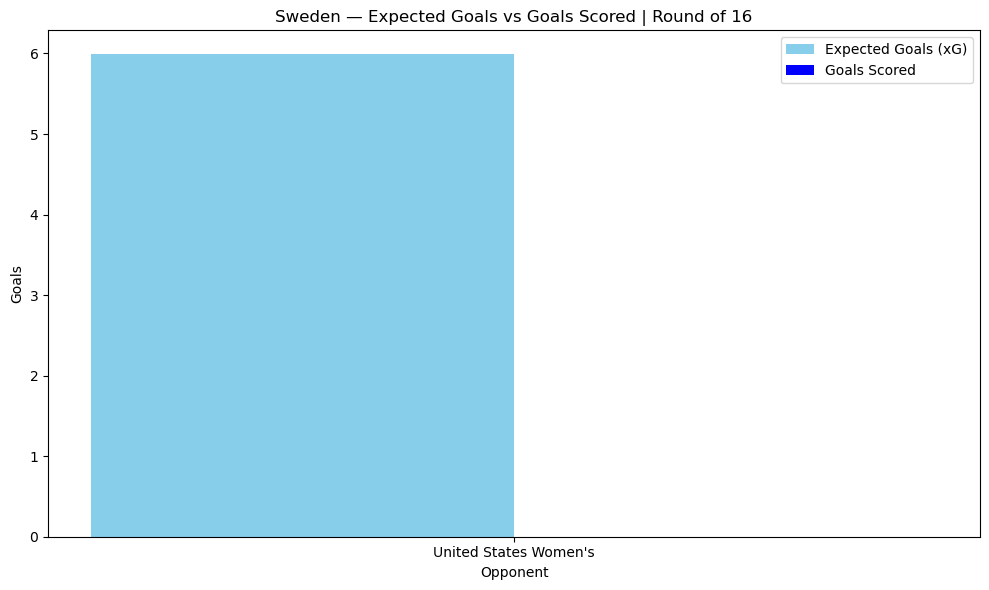

In [146]:
r16 = womens_world_cup_stats[
    (womens_world_cup_stats["team"] == "Sweden Women's") &
    (womens_world_cup_stats["stage"] == "Round of 16")
].copy()

r16["match_date"] = pd.to_datetime(r16["match_date"])

r16 = r16.sort_values("match_date")

x = np.arange(len(r16))
width = 0.35

plt.figure(figsize=(10, 6))

plt.bar(
    x - width / 2,
    r16["xG"],
    width,
    label="Expected Goals (xG)",
    color="skyblue"
)

plt.bar(
    x + width / 2,
    r16["goals_for"],
    width,
    label="Goals Scored",
    color="blue"
)

plt.xticks(
    x,
    r16["opponent"]
)

plt.xlabel("Opponent")
plt.ylabel("Goals")
plt.title("Sweden — Expected Goals vs Goals Scored | Round of 16")

plt.legend()

plt.tight_layout()
plt.show()

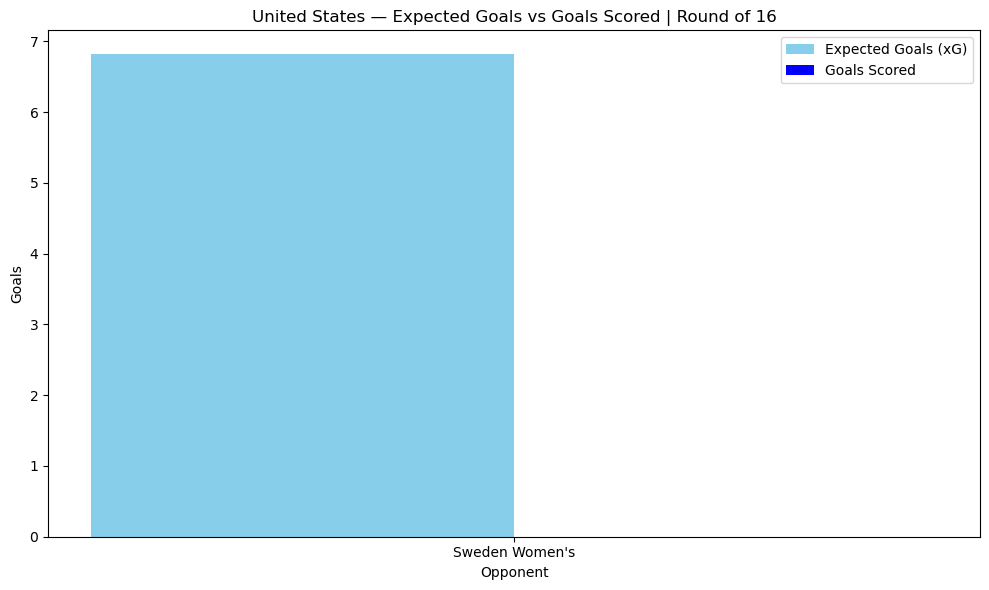

In [148]:
r16 = womens_world_cup_stats[
    (womens_world_cup_stats["team"] == "United States Women's") &
    (womens_world_cup_stats["stage"] == "Round of 16")
].copy()

r16["match_date"] = pd.to_datetime(r16["match_date"])

r16 = r16.sort_values("match_date")

x = np.arange(len(r16))
width = 0.35

plt.figure(figsize=(10, 6))

plt.bar(
    x - width / 2,
    r16["xG"],
    width,
    label="Expected Goals (xG)",
    color="skyblue"
)

plt.bar(
    x + width / 2,
    r16["goals_for"],
    width,
    label="Goals Scored",
    color="blue"
)

plt.xticks(
    x,
    r16["opponent"]
)

plt.xlabel("Opponent")
plt.ylabel("Goals")
plt.title("United States — Expected Goals vs Goals Scored | Round of 16")

plt.legend()

plt.tight_layout()
plt.show()

In [150]:
match = womens_world_cup_stats[
    (
        (womens_world_cup_stats["team"] == "Sweden Women's") &
        (womens_world_cup_stats["opponent"] == "United States Women's")
    ) |
    (
        (womens_world_cup_stats["team"] == "United States Women's") &
        (womens_world_cup_stats["opponent"] == "Sweden Women's")
    )
].copy()


# Metrics to compare

metrics = {
    "Goals": "goals_for",
    "xG": "xG",
    "Goals Minus xG": "goals_minus_xG",
    "Shots": "shots",
    "Shots on Target": "shots_on_target",
    "Saves": "saves",
    "Possession %": "possession_pct",
    "Pass Accuracy %": "pass_accuracy_pct",
    "Progressive Passes": "progressive_passes",
    "Progressive Carries": "progressive_carries",
    "Final Third Entries": "final_third_entries",
    "Box Entries": "box_entries",
    "High Turnovers": "high_turnovers",
    "Tackles Won": "tackles_won",
    "Interceptions": "interceptions",
    "Blocks": "blocks",
    "Clearances": "clearances",
    "Recoveries": "recoveries", 
    "Goals from Shots": "goals_from_shots",
    "Own Goals From": "own_goals_for",	
    "Own Goals Against": "own_goals_against",	
    "Goal type": "goal_type"
}


# Create comparison table

comparison = pd.DataFrame({
    "Metric": metrics.keys(),

    "Sweden": [
        match.loc[
            match["team"] == "Sweden Women's", column
        ].iloc[0]
        for column in metrics.values()
    ],

    "United States": [
        match.loc[
            match["team"] == "United States Women's", column
        ].iloc[0]
        for column in metrics.values()
    ]
})


# Round selected metrics to 1 decimal place

decimal_metrics = [
    "xG",
    "Goals Minus xG",
    "Possession %",
    "Pass Accuracy %"
]

comparison.loc[
    comparison["Metric"].isin(decimal_metrics),
    ["Sweden", "United States"]
] = comparison.loc[
    comparison["Metric"].isin(decimal_metrics),
    ["Sweden", "United States"]
].round(1)


# Display table

comparison

,Metric,Sweden,United States
0,Goals,0,0
1,xG,5.987829,6.815847
2,Goals Minus xG,-5.987829,-6.815847
3,Shots,16,29
4,Shots on Target,7,15
5,Saves,11,2
6,Possession %,39.72893,60.27107
7,Pass Accuracy %,71.428571,74.962519
8,Progressive Passes,85.0,118.0
9,Progressive Carries,3.0,37.0


Teams found:
["Sweden Women's" "United States Women's"]


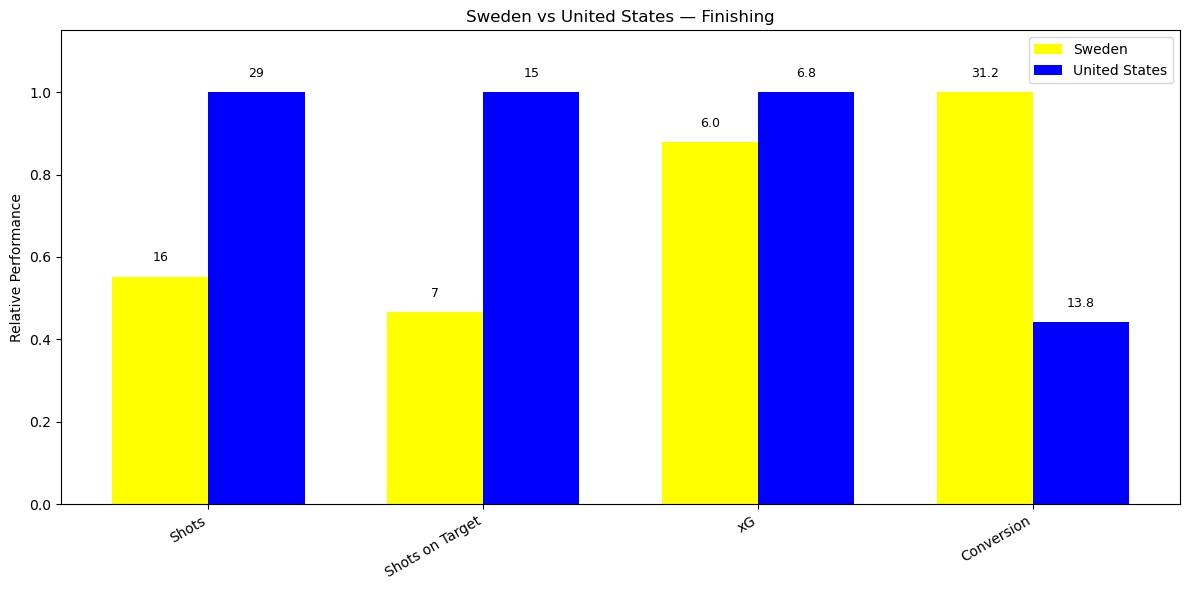

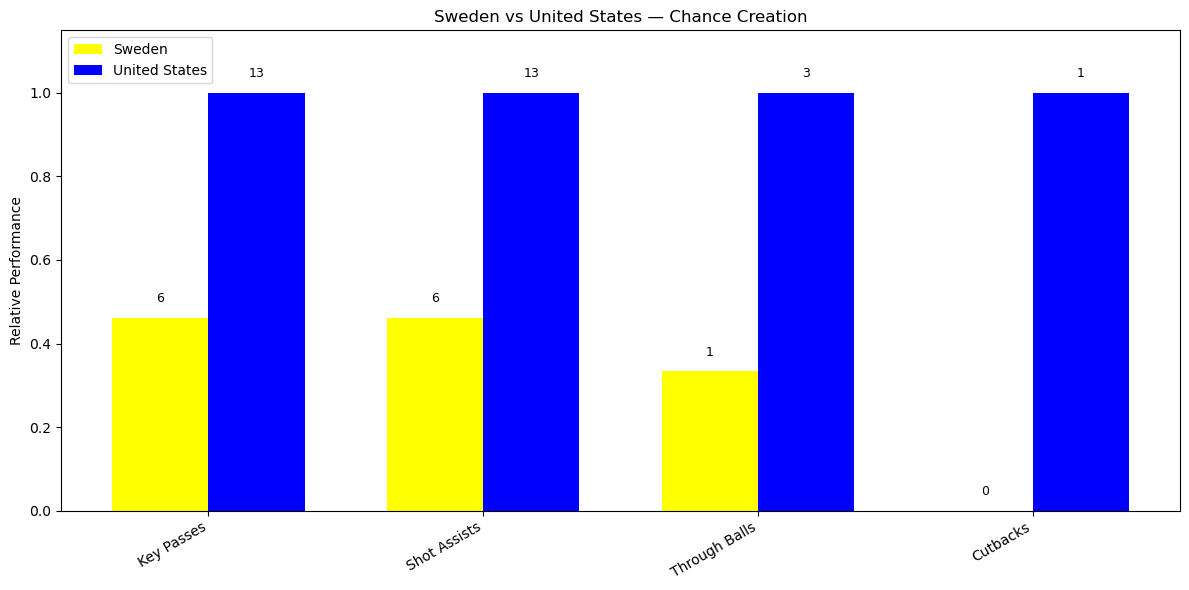

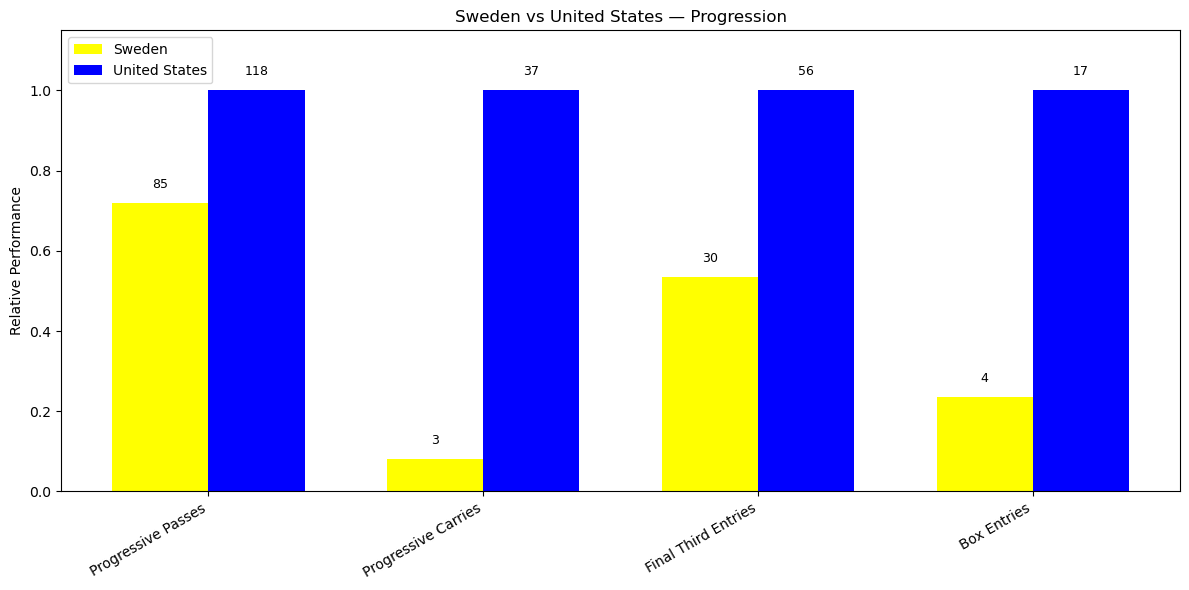

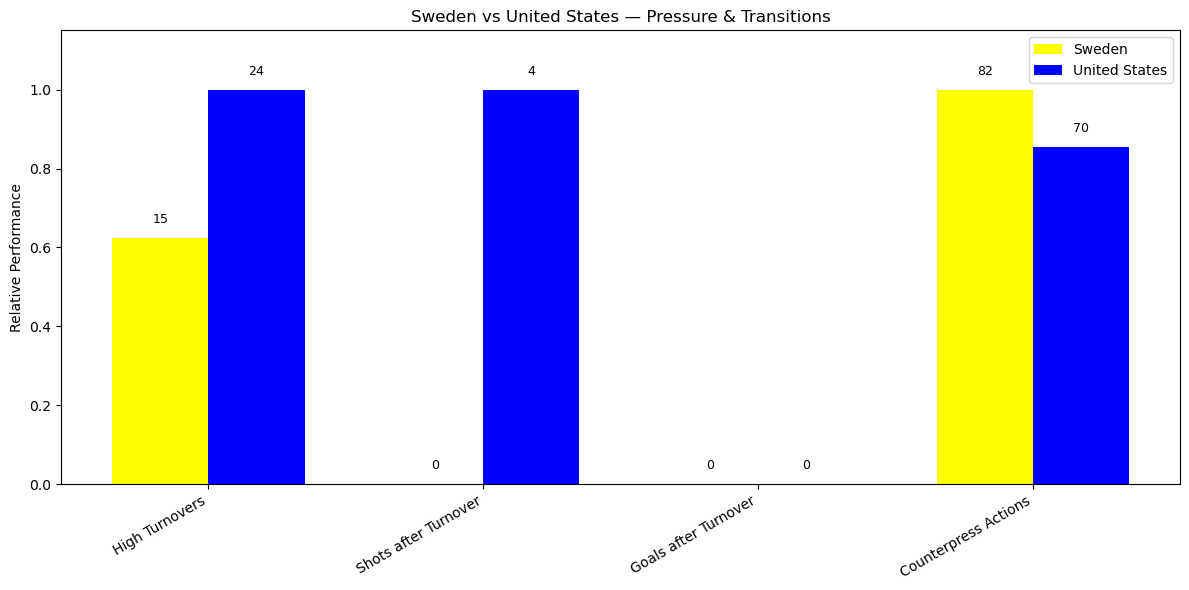

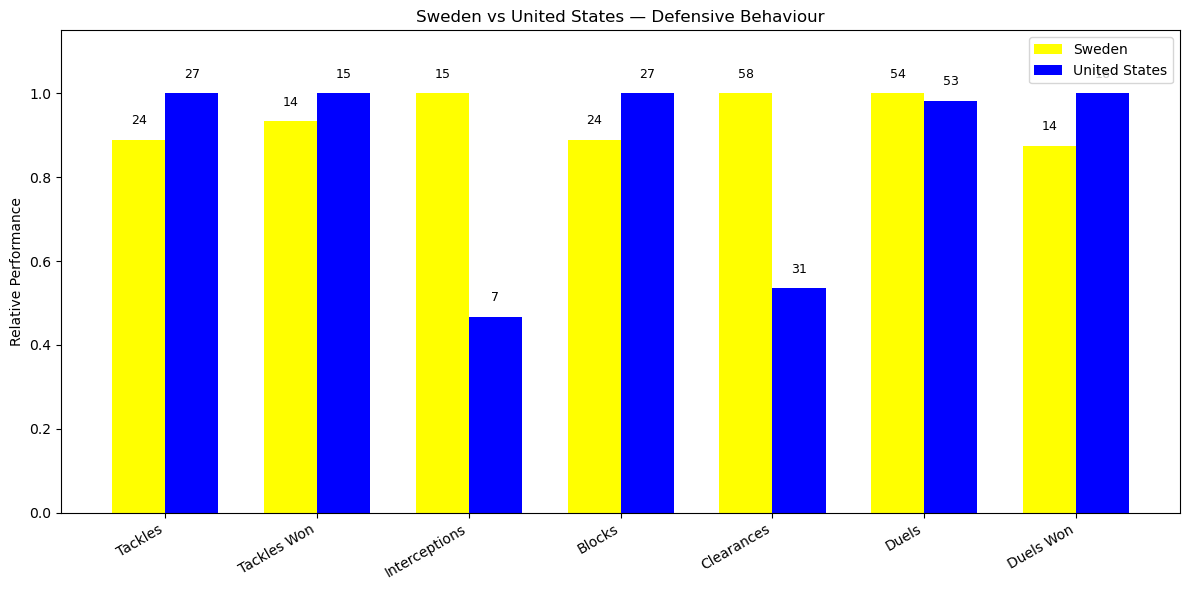

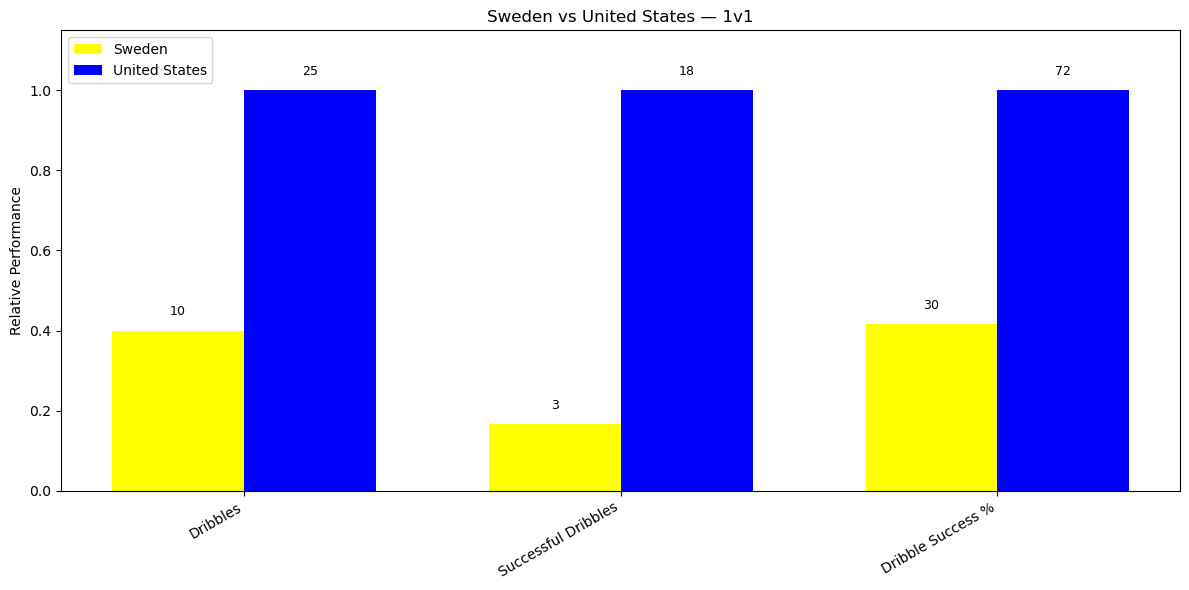

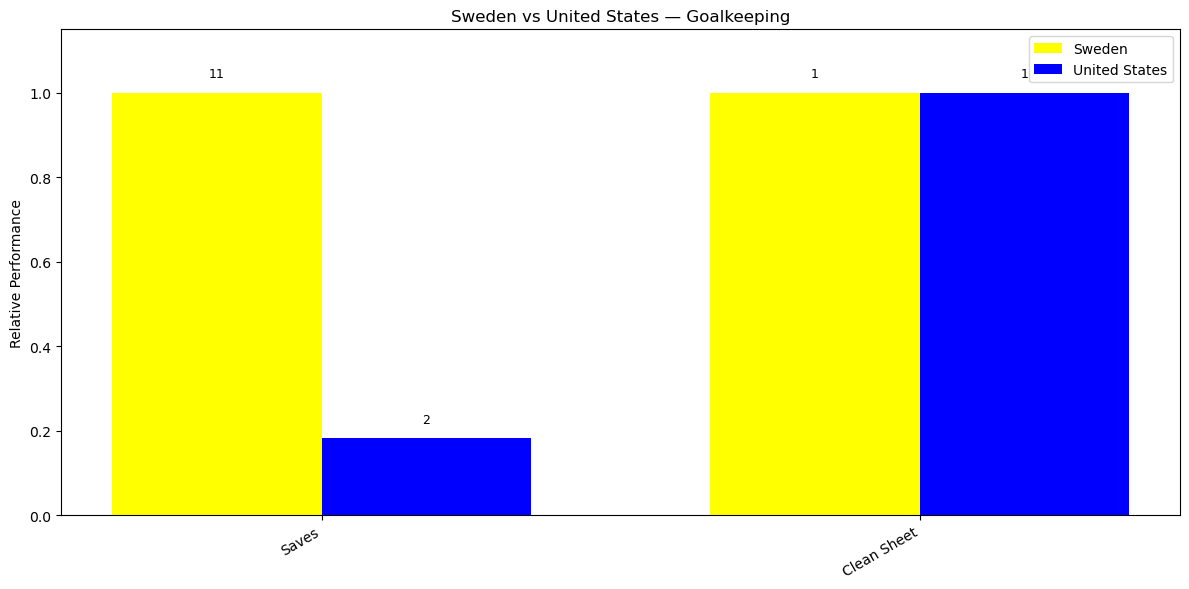

In [152]:
import matplotlib.pyplot as plt
import numpy as np


match = womens_world_cup_stats[
    (
        (womens_world_cup_stats["team"] == "Sweden Women's") &
        (womens_world_cup_stats["opponent"] == "United States Women's")
    ) |
    (
        (womens_world_cup_stats["team"] == "United States Women's") &
        (womens_world_cup_stats["opponent"] == "Sweden Women's")
    )
    &
    (womens_world_cup_stats["stage"] == "Round of 16")
].copy()


# ============================================================
# 2. TEAM NAMES
# ============================================================

team_names = {
    "Sweden": "Sweden Women's",
    "United States": "United States Women's"
}


# ============================================================
# 3. METRICS BY CATEGORY
# ============================================================

categories = {


    "Finishing": {
        "Shots": "shots",
        "Shots on Target": "shots_on_target",
        "xG": "xG",
        "Conversion": "conversion_pct"
    },


     "Chance Creation": {
        "Key Passes": "key_passes",
        "Shot Assists": "shot_assists",
        "Through Balls": "through_balls",
        "Cutbacks": "cutbacks"
    },



    "Progression": {
        "Progressive Passes": "progressive_passes",
        "Progressive Carries": "progressive_carries",
        "Final Third Entries": "final_third_entries",
        "Box Entries": "box_entries"
    },



    "Pressure & Transitions": {
        "High Turnovers": "high_turnovers",
        "Shots after Turnover": "shots_after_turnover",
        "Goals after Turnover": "goals_after_turnover",
        "Counterpress Actions": "counterpress_actions"
    },



    "Defensive Behaviour": {
        "Tackles": "tackles",
        "Tackles Won": "tackles_won",
        "Interceptions": "interceptions",
        "Blocks": "blocks",
        "Clearances": "clearances",
        "Duels": "duels",
        "Duels Won": "duels_won"
    },



    "1v1": {
        "Dribbles": "dribbles",
        "Successful Dribbles": "successful_dribbles",
        "Dribble Success %": "dribble_success_pct"
    },



    "Goalkeeping": {
        "Saves": "saves",
        "Clean Sheet": "clean_sheet"
    }
}


# ============================================================
# 4. CHECK TEAMS
# ============================================================

print("Teams found:")
print(match["team"].unique())


# ============================================================
# 5. CREATE EACH CHART
# ============================================================

for category_name, metrics in categories.items():

    # --------------------------------------------------------
    # Get real values
    # --------------------------------------------------------

    swe_values = np.array([
        match.loc[
            match["team"] == team_names["Sweden"],
            column
        ].iloc[0]
        for column in metrics.values()
    ], dtype=float)


    usa_values = np.array([
        match.loc[
            match["team"] == team_names["United States"],
            column
        ].iloc[0]
        for column in metrics.values()
    ], dtype=float)


    # --------------------------------------------------------
    # Maximum value for each metric
    # --------------------------------------------------------

    max_values = np.maximum(
        swe_values,
        usa_values
    )


    # --------------------------------------------------------
    # Normalize
    # --------------------------------------------------------

    swe_normalized = np.divide(
        swe_values,
        max_values,
        out=np.zeros_like(swe_values),
        where=max_values != 0
    )


    usa_normalized = np.divide(
        usa_values,
        max_values,
        out=np.zeros_like(usa_values),
        where=max_values != 0
    )


    # --------------------------------------------------------
    # Position of bars
    # --------------------------------------------------------

    x = np.arange(len(metrics))
    width = 0.35


    # --------------------------------------------------------
    # Create figure
    # --------------------------------------------------------

    plt.figure(figsize=(12, 6))


    bars_swe = plt.bar(
        x - width / 2,
        swe_normalized,
        width,
        label="Sweden",
        color="yellow"
    )


    bars_usa = plt.bar(
        x + width / 2,
        usa_normalized,
        width,
        label="United States",
        color="blue"
    )


    # ========================================================
    # REAL VALUES ABOVE BARS
    # ========================================================

    for bar, value in zip(
        bars_swe,
        swe_values
    ):

        if value.is_integer():
            label = f"{int(value)}"
        else:
            label = f"{value:.1f}"

        plt.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.03,
            label,
            ha="center",
            va="bottom",
            fontsize=9
        )


    for bar, value in zip(
        bars_usa,
        usa_values
    ):

        if value.is_integer():
            label = f"{int(value)}"
        else:
            label = f"{value:.1f}"

        plt.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.03,
            label,
            ha="center",
            va="bottom",
            fontsize=9
        )


    # ========================================================
    # LABELS
    # ========================================================

    plt.xticks(
        x,
        metrics.keys(),
        rotation=30,
        ha="right"
    )

    plt.ylabel("Relative Performance")

    plt.title(
        f"Sweden vs United States — {category_name}"
    )

    plt.ylim(0, 1.15)

    plt.legend()

    plt.tight_layout()

    plt.show()

In [154]:
match[[
    "team",
    "opponent",
    "formation"
]]

,team,opponent,formation
102,Sweden Women's,United States Women's,4-2-3-1
103,United States Women's,Sweden Women's,4-2-3-1


In [156]:
formation_comparison = pd.DataFrame({
    "Metric": [
        "Formation",
        "Possession %",
        "Shots",
        "xG",
        "Progressive Passes",
        "Progressive Carries",
        "Final Third Entries",
        "Box Entries",
        "High Turnovers",
        "Interceptions",
        "Clearances"
    ],

    "Sweden": [
        match.loc[
            match["team"] == "Sweden Women's",
            "formation"
        ].iloc[0],
        
        match.loc[
            match["team"] == "Sweden Women's",
            "possession_pct"
        ].iloc[0],
        
        match.loc[
            match["team"] == "Sweden Women's",
            "shots"
        ].iloc[0],
        
        match.loc[
            match["team"] == "Sweden Women's",
            "xG"
        ].iloc[0],
        
        match.loc[
            match["team"] == "Sweden Women's",
            "progressive_passes"
        ].iloc[0],
        
        match.loc[
            match["team"] == "Sweden Women's",
            "progressive_carries"
        ].iloc[0],
        
        match.loc[
            match["team"] == "Sweden Women's",
            "final_third_entries"
        ].iloc[0],
        
        match.loc[
            match["team"] == "Sweden Women's",
            "box_entries"
        ].iloc[0],
        
        match.loc[
            match["team"] == "Sweden Women's",
            "high_turnovers"
        ].iloc[0],
        
        match.loc[
            match["team"] == "Sweden Women's",
            "interceptions"
        ].iloc[0],
        
        match.loc[
            match["team"] == "Sweden Women's",
            "clearances"
        ].iloc[0]
    ],

    "United States": [
        match.loc[
            match["team"] == "United States Women's",
            "formation"
        ].iloc[0],
        
        match.loc[
            match["team"] == "United States Women's",
            "possession_pct"
        ].iloc[0],
        
        match.loc[
            match["team"] == "United States Women's",
            "shots"
        ].iloc[0],
        
        match.loc[
            match["team"] == "United States Women's",
            "xG"
        ].iloc[0],
        
        match.loc[
            match["team"] == "United States Women's",
            "progressive_passes"
        ].iloc[0],
        
        match.loc[
            match["team"] == "United States Women's",
            "progressive_carries"
        ].iloc[0],
        
        match.loc[
            match["team"] == "United States Women's",
            "final_third_entries"
        ].iloc[0],
        
        match.loc[
            match["team"] == "United States Women's",
            "box_entries"
        ].iloc[0],
        
        match.loc[
            match["team"] == "United States Women's",
            "high_turnovers"
        ].iloc[0],
        
        match.loc[
            match["team"] == "United States Women's",
            "interceptions"
        ].iloc[0],
        
        match.loc[
            match["team"] == "United States Women's",
            "clearances"
        ].iloc[0]
    ]
})

# Arredondar percentagens e xG
formation_comparison.loc[
    formation_comparison["Metric"].isin(
        ["Possession %", "xG"]
    ),
    ["Sweden", "United States"]
] = formation_comparison.loc[
    formation_comparison["Metric"].isin(
        ["Possession %", "xG"]
    ),
    ["Sweden", "United States"]
].round(1)

formation_comparison

,Metric,Sweden,United States
0,Formation,4-2-3-1,4-2-3-1
1,Possession %,39.72893,60.27107
2,Shots,16,29
3,xG,5.987829,6.815847
4,Progressive Passes,85.0,118.0
5,Progressive Carries,3.0,37.0
6,Final Third Entries,30.0,56.0
7,Box Entries,4.0,17.0
8,High Turnovers,15.0,24.0
9,Interceptions,15,7


## Conclusion SWE-USA

This was a highly competitive game despite both teams using a 4-2-3-1. The USA dominated possession, progression and chance creation, with 29 shots and 17 box entries, while Sweden showed exceptional defensive resilience through their 58 clearances, 24 blocks and 15 interceptions. Their different strengths complemented each other and kept the game goalless.

Despite the USA’s attacking dominance, neither team could convert their chances, with both recording high xG but no goals. The match was therefore decided on penalties, where Sweden won 5-4, with their defensive resilience ultimately proving decisive.